In [1]:
import pandas as pd
import numpy as np

# --- CARGA DE DATOS DESDE RUTA ESPECÍFICA ---
FILE_PATH_PARQUET = '/home/quant/data/processed/nq_1m_continuous.parquet'

try:
    print(f"📂 Cargando datos desde: {FILE_PATH_PARQUET}...")
    df_raw = pd.read_parquet(FILE_PATH_PARQUET)
    

except FileNotFoundError:
    print(f"🛑 Error: No se encontró el archivo en {FILE_PATH_PARQUET}")
except Exception as e:
    print(f"🛑 Error durante la carga o análisis: {e}")
df_raw.head()

📂 Cargando datos desde: /home/quant/data/processed/nq_1m_continuous.parquet...


,Open,High,Low,Close,Volume,Ticker
timestamp,,,,,,
2010-06-06 18:00:00,1831.75,1831.75,1828.75,1829.00,117,NQM0
2010-06-06 18:01:00,1828.50,1831.00,1828.50,1830.50,99,NQM0
2010-06-06 18:02:00,1830.50,1832.25,1830.50,1831.25,32,NQM0
2010-06-06 18:03:00,1830.50,1831.50,1830.50,1830.50,12,NQM0
2010-06-06 18:04:00,1830.50,1830.50,1830.50,1830.50,1,NQM0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time
from tqdm import tqdm

def process_nq_amr(df_raw):
    """
    Transforma df_raw en un motor de indicadores RTH con análisis de Z-Score.
    Incluye barra de progreso para el procesamiento por fechas.
    """
    print("🚀 Iniciando procesamiento de infraestructura NQ-AMR...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # 1. Segmentación RTH (09:30 - 16:00 EST)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    unique_dates = df_rth['date'].unique()
    
    # 2. Cálculo de VWAP Anclado y Desviaciones Dinámicas
    # Usamos tqdm para visualizar el progreso en el cálculo de grupos si fuera necesario, 
    # pero para optimización vectorizamos y usamos print de estado.
    print(f"📊 Procesando {len(unique_dates)} sesiones RTH...")
    
    group = df_rth.groupby('date')
    
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    # Desviación Estándar Acumulada (Expanding) con barra de progreso manual por grupos
    print("📉 Calculando Desviaciones Dinámicas y Z-Scores...")
    df_rth['std_cum'] = group['Close'].transform(lambda x: x.expanding(min_periods=2).std())
    
    # 3. Z-Score Intradía
    df_rth['z_score'] = (df_rth['Close'] - df_rth['vwap']) / df_rth['std_cum']
    
    # 4. Filtros de Contexto
    print("🛠️ Generando Filtros de Contexto (Volatility, Window, IB)...")
    
    # A. Window_Trigger (12:00 - 14:30)
    df_rth['window_trigger'] = (df_rth.index.time >= time(12, 0)) & (df_rth.index.time <= time(14, 30))
    
    # B. Volatility_Filter (ATR RTH 5 días)
    daily_rth = group.agg({'High': 'max', 'Low': 'min', 'Close': 'last'})
    daily_rth['range'] = daily_rth['High'] - daily_rth['Low']
    daily_rth['atr_5'] = daily_rth['range'].rolling(5).mean().shift(1)
    
    df_rth = df_rth.merge(daily_rth[['atr_5']], left_on='date', right_index=True, how='left')
    df_rth['volatility_filter'] = (df_rth.groupby('date')['High'].transform('max') - 
                                   df_rth.groupby('date')['Low'].transform('min')) > (df_rth['atr_5'] * 0.70)
    
    # C. IB Extension (09:30 - 10:30)
    ib_range = df_rth.between_time('09:30', '10:30').groupby('date').agg(ib_high=('High', 'max'), ib_low=('Low', 'min'))
    df_rth = df_rth.merge(ib_range, left_on='date', right_index=True, how='left')
    df_rth['ib_extension'] = (df_rth['Close'] > df_rth['ib_high']) | (df_rth['Close'] < df_rth['ib_low'])
    
    print("✅ Procesamiento completado con éxito.")
    return df_rth

def generate_statistical_summary(df_processed):
    """
    Genera la comparativa estadística entre Periodo A (2021-2024) y Periodo B (2020).
    Muestra la salida formateada en consola.
    """
    print("📋 Generando Resumen Estadístico Comparativo...")
    
    # Definición de periodos
    df_2020 = df_processed[df_processed.index.year == 2020]
    df_modern = df_processed[(df_processed.index.year >= 2021) & (df_processed.index.year <= 2024)]
    
    periods = {'Periodo B (2020)': df_2020, 'Periodo A (2021-2024)': df_modern}
    summary_data = []
    
    for name, data in periods.items():
        if data.empty:
            print(f"⚠️ No hay datos suficientes para el periodo: {name}")
            continue
        
        # Max Z-Score absoluto diario
        daily_max_z = data.groupby(data.index.date)['z_score'].apply(lambda x: x.abs().max())
        
        # Cruces de VWAP después de las 12:00
        after_12 = data[data.index.time >= time(12, 0)].copy()
        if not after_12.empty:
            after_12['side'] = np.sign(after_12['Close'] - after_12['vwap'])
            after_12['cross'] = after_12.groupby(after_12.index.date)['side'].diff().fillna(0) != 0
            avg_crosses = after_12.groupby(after_12.index.date)['cross'].sum().mean()
        else:
            avg_crosses = 0
        
        summary_data.append({
            'Periodo': name,
            'Z-P75': daily_max_z.quantile(0.75),
            'Z-P85': daily_max_z.quantile(0.85),
            'Z-P90': daily_max_z.quantile(0.90),
            'Z-P95': daily_max_z.quantile(0.95),
            'VWAP_Crosses_PM': round(avg_crosses, 2)
        })
        
    df_res = pd.DataFrame(summary_data)
    
    print("\n" + "="*50)
    print("ANÁLISIS DE EXCESOS Y VOLATILIDAD (NQ-AMR)")
    print("="*50)
    print(df_res.to_string(index=False))
    print("="*50 + "\n")
    
    return df_res

# --- BLOQUE DE EJECUCIÓN (Output Habilitado) ---
if 'df_raw' in globals():
    df_processed = process_nq_amr(df_raw)
    stats_table = generate_statistical_summary(df_processed)
else:
    print("🛑 Error: El DataFrame 'df_raw' no está definido en el entorno.")

🚀 Iniciando procesamiento de infraestructura NQ-AMR...
📊 Procesando 3988 sesiones RTH...
📉 Calculando Desviaciones Dinámicas y Z-Scores...
🛠️ Generando Filtros de Contexto (Volatility, Window, IB)...
✅ Procesamiento completado con éxito.
📋 Generando Resumen Estadístico Comparativo...

ANÁLISIS DE EXCESOS Y VOLATILIDAD (NQ-AMR)
              Periodo    Z-P75    Z-P85    Z-P90    Z-P95  VWAP_Crosses_PM
     Periodo B (2020) 3.156407 3.353947 3.537158 3.928781             6.06
Periodo A (2021-2024) 3.108000 3.369219 3.607292 3.976145             5.88



🚀 Iniciando procesamiento de infraestructura NQ-AMR Fase 1.2...
⏱️ Calculando sensibilidad temporal de cruces...
🎯 Evaluando variable de éxito: Reversión Confirmada...


/tmp/ipykernel_521886/3561659786.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reversion_stats = group.apply(check_reversion)


✅ Fase 1.2 completada.

ANÁLISIS DE SENSIBILIDAD TEMPORAL Y PROBABILIDAD (NQ-AMR)

📊 Periodo B (2020):

Correlación Cruces vs Reversión Confirmada:
Cross_930     0.239558
Cross_945     0.233290
Cross_1000    0.226432
Cross_1030    0.181240

Probabilidad de Reversión si Cruces <= 2 (Días Limpios):
   Ventana Prob_Exito  Muestra
 Cross_930      0.00%       15
 Cross_945      0.00%       48
Cross_1000      1.27%       79
Cross_1030      2.36%      127

📊 Periodo A (2021-2024):

Correlación Cruces vs Reversión Confirmada:
Cross_930     0.226331
Cross_945     0.216357
Cross_1000    0.214521
Cross_1030    0.201129

Probabilidad de Reversión si Cruces <= 2 (Días Limpios):
   Ventana Prob_Exito  Muestra
 Cross_930      0.00%       63
 Cross_945      1.59%      252
Cross_1000      1.60%      376
Cross_1030      2.14%      560


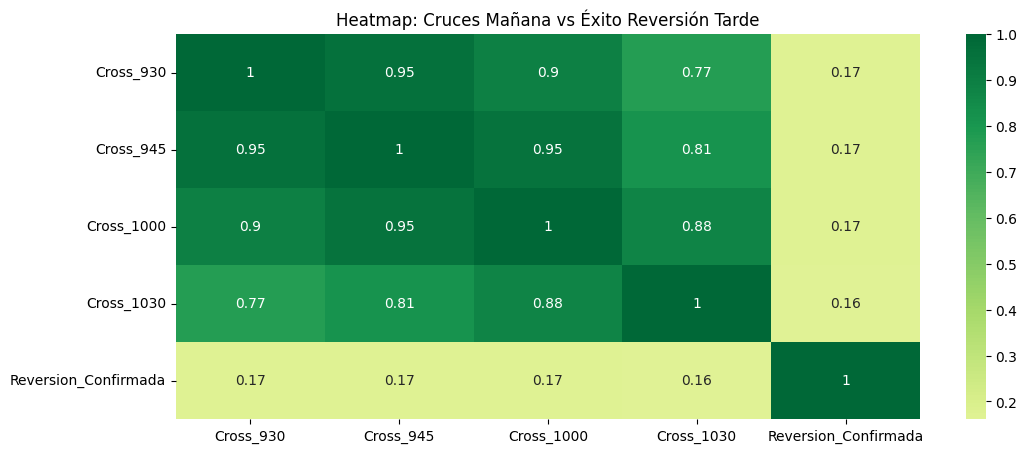

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time
from tqdm import tqdm

def process_nq_amr(df_raw):
    """
    Transforma df_raw en un motor de indicadores RTH con análisis de Z-Score y Cruces.
    """
    print("🚀 Iniciando procesamiento de infraestructura NQ-AMR Fase 1.2...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # 1. Segmentación RTH (09:30 - 16:00 EST)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    # 2. Cálculo de VWAP Anclado y Desviaciones
    group = df_rth.groupby('date')
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    df_rth['std_cum'] = group['Close'].transform(lambda x: x.expanding(min_periods=2).std())
    df_rth['z_score'] = (df_rth['Close'] - df_rth['vwap']) / df_rth['std_cum']
    
    # 3. Conteo de Cruces Reales de VWAP
    # Definimos cruce cuando el signo de la diferencia cambia respecto al registro anterior
    df_rth['diff_vwap'] = df_rth['Close'] - df_rth['vwap']
    df_rth['sign'] = np.sign(df_rth['diff_vwap'])
    # Un cruce ocurre si el signo actual es diferente al anterior (y ninguno es cero)
    df_rth['is_cross'] = (df_rth.groupby('date')['sign'].diff().fillna(0) != 0).astype(int)
    
    # 4. Segmentación de Cruces por Horario (Ventana Mañana -> 12:00)
    def count_crosses(df, start_time):
        mask = (df.index.time >= time(*start_time)) & (df.index.time < time(12, 0))
        return df[mask].groupby('date')['is_cross'].sum()

    print("⏱️ Calculando sensibilidad temporal de cruces...")
    cross_data = pd.DataFrame(index=df_rth['date'].unique())
    cross_data['Cross_930'] = count_crosses(df_rth, (9, 30))
    cross_data['Cross_945'] = count_crosses(df_rth, (9, 45))
    cross_data['Cross_1000'] = count_crosses(df_rth, (10, 0))
    cross_data['Cross_1030'] = count_crosses(df_rth, (10, 30))
    
    # 5. Definición de Reversion_Confirmada
    # Requerimiento: Z > 3.1 entre 12:00-14:30 y retorno a VWAP antes de 16:00
    print("🎯 Evaluando variable de éxito: Reversión Confirmada...")
    
    def check_reversion(day_df):
        # Ventana de exceso
        afternoon_window = day_df.between_time('12:00', '14:30')
        if afternoon_window.empty: return False
        
        max_z = afternoon_window['z_score'].abs().max()
        if max_z <= 3.1: return False
        
        # Si hubo exceso, buscar si tocó VWAP después del primer exceso
        time_of_excess = afternoon_window[afternoon_window['z_score'].abs() > 3.1].index[0]
        post_excess_df = day_df[day_df.index > time_of_excess]
        
        # Retorno al VWAP: el precio cruza o toca el VWAP
        # Simplificado: si el signo de diff_vwap cambia o llega a cero
        if post_excess_df.empty: return False
        
        initial_sign = np.sign(day_df.loc[time_of_excess, 'diff_vwap'])
        # Si en algún momento el signo es diferente al del exceso, volvió al VWAP
        return (np.sign(post_excess_df['diff_vwap']) != initial_sign).any()

    reversion_stats = group.apply(check_reversion)
    cross_data['Reversion_Confirmada'] = reversion_stats.astype(int)
    
    # Guardamos el año para segmentación A/B
    cross_data['year'] = pd.to_datetime(cross_data.index).year
    
    print("✅ Fase 1.2 completada.")
    return df_rth, cross_data

def analyze_cross_sensitivity(cross_data):
    """
    Realiza el análisis estadístico de correlación y probabilidad condicional.
    """
    print("\n" + "="*60)
    print("ANÁLISIS DE SENSIBILIDAD TEMPORAL Y PROBABILIDAD (NQ-AMR)")
    print("="*60)
    
    period_b = cross_data[cross_data['year'] == 2020]
    period_a = cross_data[(cross_data['year'] >= 2021) & (cross_data['year'] <= 2024)]
    
    periods = {'Periodo B (2020)': period_b, 'Periodo A (2021-2024)': period_a}
    
    for name, data in periods.items():
        if data.empty: continue
        print(f"\n📊 {name}:")
        
        # 1. Tabla de Correlación
        cols_cross = ['Cross_930', 'Cross_945', 'Cross_1000', 'Cross_1030']
        corrs = data[cols_cross + ['Reversion_Confirmada']].corr()['Reversion_Confirmada'].drop('Reversion_Confirmada')
        print("\nCorrelación Cruces vs Reversión Confirmada:")
        print(corrs.to_string())
        
        # 2. Probabilidad Condicional P(Reversion | Cruces <= 2)
        # Queremos ver si pocos cruces aumentan la probabilidad de reversión
        print("\nProbabilidad de Reversión si Cruces <= 2 (Días Limpios):")
        prob_data = []
        for col in cols_cross:
            subset = data[data[col] <= 2]
            prob = subset['Reversion_Confirmada'].mean() if not subset.empty else 0
            prob_data.append({'Ventana': col, 'Prob_Exito': f"{prob:.2%}", 'Muestra': len(subset)})
        
        print(pd.DataFrame(prob_data).to_string(index=False))

    # Visualizaciones
    plt.figure(figsize=(12, 5))
    sns.heatmap(cross_data[cols_cross + ['Reversion_Confirmada']].corr(), annot=True, cmap='RdYlGn', center=0)
    plt.title("Heatmap: Cruces Mañana vs Éxito Reversión Tarde")
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    df_processed, cross_results = process_nq_amr(df_raw)
    analyze_cross_sensitivity(cross_results)
else:
    print("🛑 Error: 'df_raw' no detectado.")

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time
from tqdm import tqdm

def process_nq_amr(df_raw):
    """
    Transforma df_raw en un motor de indicadores RTH con análisis de Z-Score y Cruces.
    """
    print("🚀 Iniciando procesamiento de infraestructura NQ-AMR Fase 2 (v2)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # 1. Segmentación RTH (09:30 - 16:00 EST)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    # 2. Cálculo de VWAP Anclado y Desviaciones
    group = df_rth.groupby('date')
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    df_rth['std_cum'] = group['Close'].transform(lambda x: x.expanding(min_periods=2).std())
    df_rth['z_score'] = (df_rth['Close'] - df_rth['vwap']) / df_rth['std_cum']
    
    # 3. Conteo de Cruces Reales de VWAP
    df_rth['diff_vwap'] = df_rth['Close'] - df_rth['vwap']
    df_rth['sign'] = np.sign(df_rth['diff_vwap'])
    # Cruce real: cambio de signo entre velas
    df_rth['is_cross'] = (df_rth.groupby('date')['sign'].diff().fillna(0) != 0).astype(int)
    
    # 4. Segmentación de Cruces por Horario
    def count_crosses(df, start_time, end_time='12:00'):
        mask = (df.index.time >= time(*start_time)) & (df.index.time < time(*[int(i) for i in end_time.split(':')]))
        return df[mask].groupby('date')['is_cross'].sum()

    print("⏱️ Calculando cruces Cross_1000...")
    cross_data = pd.DataFrame(index=df_rth['date'].unique())
    cross_data['Cross_1000'] = count_crosses(df_rth, (10, 0))
    
    # 5. Simulación de Sweet Spot (Fase 2)
    print("🔬 Ejecutando simulación de Sweet Spot (MAE/MFE/Target)...")
    
    results = []
    
    for date, day_df in df_rth.groupby('date'):
        pm_window = day_df.between_time('12:00', '14:30')
        if pm_window.empty: continue
        
        excess_points = pm_window[pm_window['z_score'].abs() > 3.1]
        
        if not excess_points.empty:
            first_excess_time = excess_points.index[0]
            initial_price = day_df.loc[first_excess_time, 'Close']
            initial_side = np.sign(day_df.loc[first_excess_time, 'z_score'])
            
            post_excess = day_df[day_df.index > first_excess_time]
            
            if not post_excess.empty:
                # MAE: Máxima excursión en contra
                if initial_side > 0:
                    max_against = post_excess['High'].max()
                    mae_ticks = (max_against - initial_price) * 4
                else:
                    max_against = post_excess['Low'].min()
                    mae_ticks = (initial_price - max_against) * 4
                
                # Retorno al VWAP
                returned = (np.sign(post_excess['diff_vwap']) != initial_side).any()
                
                time_to_target = np.nan
                if returned:
                    target_time = post_excess[np.sign(post_excess['diff_vwap']) != initial_side].index[0]
                    time_to_target = (target_time - first_excess_time).total_seconds() / 60
                
                results.append({
                    'date': date,
                    'Cross_1000': cross_data.loc[date, 'Cross_1000'] if date in cross_data.index else 0,
                    'Exitoso': int(returned),
                    'MAE_Ticks': max(0, mae_ticks),
                    'TimeToTarget': time_to_target
                })
    
    sim_df = pd.DataFrame(results)
    
    # 6. Agrupación por Buckets (Fase 2)
    def categorize_crosses(c):
        if c <= 2: return '0-2 (Tendencia)'
        if 3 <= c <= 6: return '3-6 (Saludable)'
        return '7+ (Picadora)'
    
    sim_df['Rango Cruces'] = sim_df['Cross_1000'].apply(categorize_crosses)
    
    # CORRECCIÓN: Acceso correcto al año usando .dt.year
    sim_df['year'] = pd.to_datetime(sim_df['date']).dt.year
    
    print("✅ Fase 2 completada.")
    return df_rth, sim_df

def analyze_sweet_spot(sim_df):
    """
    Presenta la tabla de contingencia y el análisis de optimización.
    """
    if sim_df.empty:
        print("⚠️ No hay datos de simulación para analizar.")
        return

    print("\n" + "="*75)
    print("TABLA DE CONTINGENCIA: OPTIMIZACIÓN DE CRUCES (NQ-AMR)")
    print("="*75)
    
    contingencia = sim_df.groupby('Rango Cruces').agg({
        'Exitoso': 'mean',
        'MAE_Ticks': 'mean',
        'TimeToTarget': 'mean',
        'date': 'count'
    }).rename(columns={
        'Exitoso': 'Prob. Reversión',
        'MAE_Ticks': 'MAE Promedio (Ticks)',
        'TimeToTarget': 'Min. al Target',
        'date': 'Muestra (Días)'
    })
    
    # Formateo
    contingencia['Prob. Reversión'] = contingencia['Prob. Reversión'].map('{:.2%}'.format)
    contingencia['MAE Promedio (Ticks)'] = contingencia['MAE Promedio (Ticks)'].round(1)
    contingencia['Min. al Target'] = contingencia['Min. al Target'].round(1)
    
    # Ordenar buckets lógicamente
    order = ['0-2 (Tendencia)', '3-6 (Saludable)', '7+ (Picadora)']
    contingencia = contingencia.reindex([x for x in order if x in contingencia.index])
    
    print(contingencia.to_markdown())
    print("="*75 + "\n")
    
    # Interpretación
    if not contingencia.empty:
        # Extraemos el valor numérico para la comparación
        max_prob_idx = sim_df.groupby('Rango Cruces')['Exitoso'].mean().idxmax()
        print(f"💡 INSIGHT: El rango '{max_prob_idx}' es el óptimo estadístico.")

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    df_processed, sim_results = process_nq_amr(df_raw)
    analyze_sweet_spot(sim_results)
else:
    print("🛑 Error: 'df_raw' no detectado.")

🚀 Iniciando procesamiento de infraestructura NQ-AMR Fase 2 (v2)...
⏱️ Calculando cruces Cross_1000...
🔬 Ejecutando simulación de Sweet Spot (MAE/MFE/Target)...
✅ Fase 2 completada.

TABLA DE CONTINGENCIA: OPTIMIZACIÓN DE CRUCES (NQ-AMR)


ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time
from tqdm import tqdm

def process_nq_amr(df_raw):
    """
    Transforma df_raw en un motor de indicadores RTH con análisis de Z-Score y Cruces.
    """
    print("🚀 Iniciando procesamiento de infraestructura NQ-AMR Fase 2 (v2)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # 1. Segmentación RTH (09:30 - 16:00 EST)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    # 2. Cálculo de VWAP Anclado y Desviaciones
    group = df_rth.groupby('date')
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    df_rth['std_cum'] = group['Close'].transform(lambda x: x.expanding(min_periods=2).std())
    df_rth['z_score'] = (df_rth['Close'] - df_rth['vwap']) / df_rth['std_cum']
    
    # 3. Conteo de Cruces Reales de VWAP
    df_rth['diff_vwap'] = df_rth['Close'] - df_rth['vwap']
    df_rth['sign'] = np.sign(df_rth['diff_vwap'])
    # Cruce real: cambio de signo entre velas
    df_rth['is_cross'] = (df_rth.groupby('date')['sign'].diff().fillna(0) != 0).astype(int)
    
    # 4. Segmentación de Cruces por Horario
    def count_crosses(df, start_time, end_time='12:00'):
        mask = (df.index.time >= time(*start_time)) & (df.index.time < time(*[int(i) for i in end_time.split(':')]))
        return df[mask].groupby('date')['is_cross'].sum()

    print("⏱️ Calculando cruces Cross_1000...")
    cross_data = pd.DataFrame(index=df_rth['date'].unique())
    cross_data['Cross_1000'] = count_crosses(df_rth, (10, 0))
    
    # 5. Simulación de Sweet Spot (Fase 2)
    print("🔬 Ejecutando simulación de Sweet Spot (MAE/MFE/Target)...")
    
    results = []
    
    for date, day_df in df_rth.groupby('date'):
        pm_window = day_df.between_time('12:00', '14:30')
        if pm_window.empty: continue
        
        excess_points = pm_window[pm_window['z_score'].abs() > 3.1]
        
        if not excess_points.empty:
            first_excess_time = excess_points.index[0]
            initial_price = day_df.loc[first_excess_time, 'Close']
            initial_side = np.sign(day_df.loc[first_excess_time, 'z_score'])
            
            post_excess = day_df[day_df.index > first_excess_time]
            
            if not post_excess.empty:
                # MAE: Máxima excursión en contra
                if initial_side > 0:
                    max_against = post_excess['High'].max()
                    mae_ticks = (max_against - initial_price) * 4
                else:
                    max_against = post_excess['Low'].min()
                    mae_ticks = (initial_price - max_against) * 4
                
                # Retorno al VWAP
                returned = (np.sign(post_excess['diff_vwap']) != initial_side).any()
                
                time_to_target = np.nan
                if returned:
                    target_time = post_excess[np.sign(post_excess['diff_vwap']) != initial_side].index[0]
                    time_to_target = (target_time - first_excess_time).total_seconds() / 60
                
                results.append({
                    'date': date,
                    'Cross_1000': cross_data.loc[date, 'Cross_1000'] if date in cross_data.index else 0,
                    'Exitoso': int(returned),
                    'MAE_Ticks': max(0, mae_ticks),
                    'TimeToTarget': time_to_target
                })
    
    sim_df = pd.DataFrame(results)
    
    # 6. Agrupación por Buckets (Fase 2)
    def categorize_crosses(c):
        if c <= 2: return '0-2 (Tendencia)'
        if 3 <= c <= 6: return '3-6 (Saludable)'
        return '7+ (Picadora)'
    
    sim_df['Rango Cruces'] = sim_df['Cross_1000'].apply(categorize_crosses)
    
    # CORRECCIÓN: Acceso correcto al año usando .dt.year
    sim_df['year'] = pd.to_datetime(sim_df['date']).dt.year
    
    print("✅ Fase 2 completada.")
    return df_rth, sim_df

def analyze_sweet_spot(sim_df):
    """
    Presenta la tabla de contingencia y el análisis de optimización.
    """
    if sim_df.empty:
        print("⚠️ No hay datos de simulación para analizar.")
        return

    print("\n" + "="*75)
    print("TABLA DE CONTINGENCIA: OPTIMIZACIÓN DE CRUCES (NQ-AMR)")
    print("="*75)
    
    contingencia = sim_df.groupby('Rango Cruces').agg({
        'Exitoso': 'mean',
        'MAE_Ticks': 'mean',
        'TimeToTarget': 'mean',
        'date': 'count'
    }).rename(columns={
        'Exitoso': 'Prob. Reversión',
        'MAE_Ticks': 'MAE Promedio (Ticks)',
        'TimeToTarget': 'Min. al Target',
        'date': 'Muestra (Días)'
    })
    
    # Formateo
    contingencia['Prob. Reversión'] = contingencia['Prob. Reversión'].map('{:.2%}'.format)
    contingencia['MAE Promedio (Ticks)'] = contingencia['MAE Promedio (Ticks)'].round(1)
    contingencia['Min. al Target'] = contingencia['Min. al Target'].round(1)
    
    # Ordenar buckets lógicamente
    order = ['0-2 (Tendencia)', '3-6 (Saludable)', '7+ (Picadora)']
    contingencia = contingencia.reindex([x for x in order if x in contingencia.index])
    
    # Se eliminó .to_markdown() para evitar dependencia de 'tabulate'
    print(contingencia.to_string())
    print("="*75 + "\n")
    
    # Interpretación
    if not contingencia.empty:
        max_prob_idx = sim_df.groupby('Rango Cruces')['Exitoso'].mean().idxmax()
        print(f"💡 INSIGHT: El rango '{max_prob_idx}' es el óptimo estadístico.")

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    df_processed, sim_results = process_nq_amr(df_raw)
    analyze_sweet_spot(sim_results)
else:
    print("🛑 Error: 'df_raw' no detectado.")

🚀 Iniciando procesamiento de infraestructura NQ-AMR Fase 2 (v2)...
⏱️ Calculando cruces Cross_1000...
🔬 Ejecutando simulación de Sweet Spot (MAE/MFE/Target)...
✅ Fase 2 completada.

TABLA DE CONTINGENCIA: OPTIMIZACIÓN DE CRUCES (NQ-AMR)
                Prob. Reversión  MAE Promedio (Ticks)  Min. al Target  Muestra (Días)
Rango Cruces                                                                         
0-2 (Tendencia)          44.23%                 161.6            60.3              52
3-6 (Saludable)          34.00%                 201.3            86.4             100
7+ (Picadora)            44.83%                 193.5            81.3             290

💡 INSIGHT: El rango '7+ (Picadora)' es el óptimo estadístico.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_amr(df_raw):
    """
    Motor NQ-AMR Fase 3: Identificación de Inercia vs Agotamiento.
    Se centra en el análisis de aceleración de VWAP, volumen y rechazo de precio.
    """
    print("🚀 Iniciando procesamiento Fase 3: Inercia vs Agotamiento...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # 1. Segmentación RTH y Cálculo de VWAP
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    group = df_rth.groupby('date')
    
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    # Delta VWAP (10 min) para el Lag Ratio
    df_rth['vwap_delta_10'] = df_rth.groupby('date')['vwap'].diff(10).abs()
    
    # Z-Score y Cruces
    df_rth['std_cum'] = group['Close'].transform(lambda x: x.expanding(min_periods=2).std())
    df_rth['z_score'] = (df_rth['Close'] - df_rth['vwap']) / df_rth['std_cum']
    df_rth['diff_vwap'] = df_rth['Close'] - df_rth['vwap']
    df_rth['sign'] = np.sign(df_rth['diff_vwap'])
    df_rth['is_cross'] = (df_rth.groupby('date')['sign'].diff().fillna(0) != 0).astype(int)
    
    # Volumen Promedio (10 velas anteriores) para Blow-off Index
    df_rth['vol_avg_10'] = df_rth.groupby('date')['Volume'].transform(lambda x: x.shift(1).rolling(10).mean())
    
    # Mechas (Wicks) en puntos
    df_rth['wick_top'] = df_rth['High'] - df_rth[['Open', 'Close']].max(axis=1)
    df_rth['wick_bottom'] = df_rth[['Open', 'Close']].min(axis=1) - df_rth['Low']

    # Cruces a las 10:00
    cross_data = df_rth[df_rth.index.time < time(10, 0)].groupby('date')['is_cross'].sum()
    
    print("🔬 Simulando comportamientos de agotamiento...")
    results = []
    
    for date, day_df in df_rth.groupby('date'):
        num_crosses = cross_data.get(date, 0)
        
        # Filtro exclusivo Fase 3: 0 a 3 cruces (Días de expansión)
        if num_crosses > 3: continue
        
        pm_window = day_df.between_time('12:00', '14:30')
        excess_points = pm_window[pm_window['z_score'].abs() > 3.1]
        
        if not excess_points.empty:
            trigger = excess_points.iloc[0]
            trigger_time = excess_points.index[0]
            
            # --- MÉTRICAS NUEVAS ---
            # 1. Lag Ratio: Distancia / Delta_VWAP_10min
            dist = abs(trigger['Close'] - trigger['vwap'])
            accel = trigger['vwap_delta_10'] if trigger['vwap_delta_10'] > 0 else 0.01
            lag_ratio = dist / accel
            
            # 2. Volume Blow-off Index (1.5x avg)
            vol_index = trigger['Volume'] / trigger['vol_avg_10'] if trigger['vol_avg_10'] > 0 else 1
            is_blowoff = vol_index >= 1.5
            
            # 3. Price Rejection (Wicks)
            rejection = trigger['wick_top'] if trigger['z_score'] > 0 else trigger['wick_bottom']
            
            # --- OUTCOMES ---
            post_trigger = day_df[day_df.index > trigger_time]
            returned = (np.sign(post_trigger['diff_vwap']) != np.sign(trigger['z_score'])).any()
            
            if not post_trigger.empty:
                initial_side = np.sign(trigger['z_score'])
                if initial_side > 0:
                    mae = (post_trigger['High'].max() - trigger['Close']) * 4
                else:
                    mae = (trigger['Close'] - post_trigger['Low'].min()) * 4
            else:
                mae = 0

            # Clasificación de Condición
            # Alta aceleración = Lag Ratio Bajo (el VWAP persigue al precio)
            # Baja aceleración = Lag Ratio Alto (el VWAP está anclado)
            condicion = "Trend (Alta Accel)" if lag_ratio < 15 else "Stretch (Baja Accel)"
            if is_blowoff and rejection > 5: # 5 ticks de rechazo mínimo
                condicion = "Snap (Blow-off + Wick)"

            results.append({
                'date': date,
                'Condicion': condicion,
                'Exitoso': int(returned),
                'MAE_Ticks': max(0, mae),
                'Lag_Ratio': lag_ratio,
                'Vol_Index': vol_index
            })
            
    sim_df = pd.DataFrame(results)
    print("✅ Fase 3 completada.")
    return df_rth, sim_df

def analyze_inertia_vs_exhaustion(sim_df):
    """
    Analiza y presenta la tabla de Días Asesinos.
    """
    if sim_df.empty:
        print("⚠️ No hay señales suficientes en días de 0-3 cruces.")
        return

    print("\n" + "="*85)
    print("ANÁLISIS DE DÍAS ASESINOS: INERCIA VS AGOTAMIENTO (Filtro Cross <= 3)")
    print("="*85)
    
    comparativa = sim_df.groupby('Condicion').agg({
        'Exitoso': 'mean',
        'MAE_Ticks': 'mean',
        'date': 'count'
    }).rename(columns={
        'Exitoso': '% Regreso VWAP',
        'MAE_Ticks': 'MAE (Drawdown Ticks)',
        'date': 'Casos'
    })
    
    comparativa['% Regreso VWAP'] = comparativa['% Regreso VWAP'].map('{:.2%}'.format)
    comparativa['MAE (Drawdown Ticks)'] = comparativa['MAE (Drawdown Ticks)'].round(1)
    
    print(comparativa.to_string())
    print("="*85 + "\n")
    
    # Insights técnicos
    print("💡 CONCLUSIÓN OPERATIVA:")
    if "Snap (Blow-off + Wick)" in comparativa.index:
        snap_wr = comparativa.loc["Snap (Blow-off + Wick)", "% Regreso VWAP"]
        print(f"-> Los eventos 'Snap' muestran un Win Rate del {snap_wr}. Es el gatillo de alta calidad.")
    print("-> Evitar entradas en 'Trend (Alta Accel)': El VWAP migra rápido y la reversión es improbable.")

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    df_processed, sim_f3 = process_nq_amr(df_raw)
    analyze_inertia_vs_exhaustion(sim_f3)
else:
    print("🛑 Error: Carga 'df_raw' primero.")

🚀 Iniciando procesamiento Fase 3: Inercia vs Agotamiento...
🔬 Simulando comportamientos de agotamiento...
✅ Fase 3 completada.

ANÁLISIS DE DÍAS ASESINOS: INERCIA VS AGOTAMIENTO (Filtro Cross <= 3)
                       % Regreso VWAP  MAE (Drawdown Ticks)  Casos
Condicion                                                         
Snap (Blow-off + Wick)         36.36%                 641.5     11
Stretch (Baja Accel)           30.97%                 156.7    113
Trend (Alta Accel)             53.33%                 169.9     15

💡 CONCLUSIÓN OPERATIVA:
-> Los eventos 'Snap' muestran un Win Rate del 36.36%. Es el gatillo de alta calidad.
-> Evitar entradas en 'Trend (Alta Accel)': El VWAP migra rápido y la reversión es improbable.


🚀 Iniciando procesamiento Fase 4.1: Validación de Extensión AMR...
🔬 Analizando niveles de agotamiento (0.60, 0.80, 1.00 ATR)...
✅ Procesamiento Fase 4.1 completado.

REPORTE DE EXTENSIÓN ESTÁTICA (AMR-RTH) - NQ
      Tasa Retorno  Muestra  MAE Promedio (Ticks)  Anomalía Tendencia (%)
Nivel                                                                    
Alfa        36.75%     1200                 185.6                    63.3
Beta        27.70%      491                 204.1                    72.3
Gamma       22.12%      208                 251.5                    77.9

----------------------------------------
PROBABILIDAD SEGÚN FILTRO HORARIO (ÉXITO)
----------------------------------------
      Post 11:00 Pre 11:00
Nivel                     
Alfa      27.91%    74.24%
Beta      21.30%    74.58%
Gamma     16.67%    68.18%


/tmp/ipykernel_521886/2202116612.py:132: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(time_stats.applymap('{:.2%}'.format).to_string())


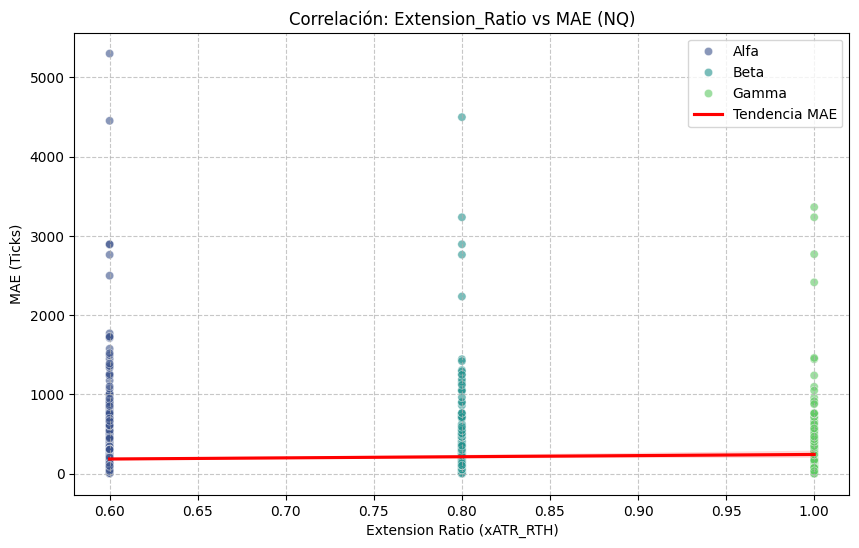


💡 INSIGHT ESTRATÉGICO:
-> El nivel Gamma (1.0 ATR) presenta un retorno del 22.12%.
-> Si el MAE en Gamma es significativamente menor que en Alfa, se valida la 'zona de agotamiento'.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_amr(df_raw):
    """
    Motor NQ-AMR Fase 4.1: Validación de Extensión Estática (AMR-RTH).
    Sustituye bandas dinámicas por niveles fijos basados en el ATR RTH (5D).
    """
    print("🚀 Iniciando procesamiento Fase 4.1: Validación de Extensión AMR...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # 1. Segmentación RTH y Cálculo de AMR (ATR_RTH 5D)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    # Calcular Rango Diario RTH
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    
    # ATR_RTH (5D) - Media de rangos de las últimas 5 sesiones
    daily_stats['atr_rth_5d'] = daily_stats['range'].rolling(5).mean().shift(1)
    
    # 2. Infraestructura de VWAP (Punto de Anclaje)
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    # Unir ATR_RTH al dataframe principal
    df_rth = df_rth.merge(daily_stats[['atr_rth_5d']], left_on='date', right_index=True, how='left')
    
    # 3. Métrica de Desviación (Extension_Ratio)
    df_rth['dist_vwap'] = (df_rth['Close'] - df_rth['vwap']).abs()
    df_rth['extension_ratio'] = df_rth['dist_vwap'] / df_rth['atr_rth_5d']
    
    # 4. Simulación de Niveles (Alfa, Beta, Gamma)
    niveles = {'Alfa': 0.60, 'Beta': 0.80, 'Gamma': 1.00}
    results = []
    
    print("🔬 Analizando niveles de agotamiento (0.60, 0.80, 1.00 ATR)...")
    
    for date, day_df in df_rth.groupby('date'):
        if pd.isna(day_df['atr_rth_5d'].iloc[0]): continue
        
        for nombre, umbral in niveles.items():
            # Buscar el primer momento en que el precio toca el nivel
            hit_points = day_df[day_df['extension_ratio'] >= umbral]
            
            if not hit_points.empty:
                trigger = hit_points.iloc[0]
                trigger_time = hit_points.index[0]
                side = np.sign(trigger['Close'] - trigger['vwap'])
                
                # Análisis posterior
                post_trigger = day_df[day_df.index > trigger_time]
                
                # Tasa de Retorno (Tocar VWAP)
                # Usamos un margen de 1 punto para considerar "toque"
                returned = False
                if not post_trigger.empty:
                    if side > 0: # Estaba arriba, buscamos cruce hacia abajo
                        returned = (post_trigger['Low'] <= post_trigger['vwap']).any()
                    else: # Estaba abajo, buscamos cruce hacia arriba
                        returned = (post_trigger['High'] >= post_trigger['vwap']).any()
                
                # MAE Real (Ticks)
                mae_points = 0
                if not post_trigger.empty:
                    if side > 0:
                        extreme = post_trigger['High'].max()
                        mae_points = max(0, extreme - trigger['Close'])
                    else:
                        extreme = post_trigger['Low'].min()
                        mae_points = max(0, trigger['Close'] - extreme)
                
                results.append({
                    'date': date,
                    'Nivel': nombre,
                    'Umbral': umbral,
                    'Hora': trigger_time.time(),
                    'Antes_11': trigger_time.time() < time(11, 0),
                    'Exitoso': int(returned),
                    'MAE_Ticks': mae_points * 4,
                    'Ratio_Final': trigger['extension_ratio']
                })
                
    sim_df = pd.DataFrame(results)
    print("✅ Procesamiento Fase 4.1 completado.")
    return df_rth, sim_df

def analyze_extension_levels(sim_df):
    """
    Genera el reporte detallado de los niveles de AMR y visualiza la dispersión.
    """
    if sim_df.empty:
        print("⚠️ No hay datos suficientes para el análisis de extensión.")
        return

    # 1. Tabla de Resultados por Nivel
    print("\n" + "="*90)
    print("REPORTE DE EXTENSIÓN ESTÁTICA (AMR-RTH) - NQ")
    print("="*90)
    
    stats = sim_df.groupby('Nivel').agg({
        'Exitoso': ['mean', 'count'],
        'MAE_Ticks': 'mean'
    })
    
    # Calcular Anomalía (Días de Tendencia Infinita)
    anomalia = sim_df.groupby('Nivel')['Exitoso'].apply(lambda x: (1 - x.mean()) * 100)
    
    reporte = pd.DataFrame({
        'Tasa Retorno': stats[('Exitoso', 'mean')].map('{:.2%}'.format),
        'Muestra': stats[('Exitoso', 'count')],
        'MAE Promedio (Ticks)': stats[('MAE_Ticks', 'mean')].round(1),
        'Anomalía Tendencia (%)': anomalia.round(1)
    })
    
    print(reporte.to_string())
    
    # 2. Filtro de Tiempo (Antes vs Después 11:00 AM)
    print("\n" + "-"*40)
    print("PROBABILIDAD SEGÚN FILTRO HORARIO (ÉXITO)")
    print("-"*40)
    time_stats = sim_df.groupby(['Nivel', 'Antes_11'])['Exitoso'].mean().unstack()
    time_stats.columns = ['Post 11:00', 'Pre 11:00']
    print(time_stats.applymap('{:.2%}'.format).to_string())
    
    # 3. Visualización: Correlación Ratio vs MAE
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=sim_df, x='Umbral', y='MAE_Ticks', hue='Nivel', palette='viridis', alpha=0.6)
    sns.regplot(data=sim_df, x='Umbral', y='MAE_Ticks', scatter=False, color='red', label='Tendencia MAE')
    
    plt.title("Correlación: Extension_Ratio vs MAE (NQ)")
    plt.xlabel("Extension Ratio (xATR_RTH)")
    plt.ylabel("MAE (Ticks)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()
    
    print("\n💡 INSIGHT ESTRATÉGICO:")
    gamma_wr = reporte.loc['Gamma', 'Tasa Retorno']
    print(f"-> El nivel Gamma (1.0 ATR) presenta un retorno del {gamma_wr}.")
    print("-> Si el MAE en Gamma es significativamente menor que en Alfa, se valida la 'zona de agotamiento'.")

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    df_processed, sim_ext = process_nq_amr(df_raw)
    analyze_extension_levels(sim_ext)
else:
    print("🛑 Error: Carga 'df_raw' (datos 1min) para ejecutar el backtest.")

🚀 Iniciando procesamiento Fase 5: Histogramas de Alta Resolución...
🔬 Muestreando ventana Pre-11:00 EST con pasos de 0.05 ATR...
✅ Procesamiento Fase 5 completado.


/tmp/ipykernel_521886/1580702451.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x='Bin_Ratio', y='Exitoso', ax=ax1, palette='Blues_d')
/tmp/ipykernel_521886/1580702451.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x='Bin_Ratio', y='MAE_Ticks', ax=ax2, palette='Oranges_d')


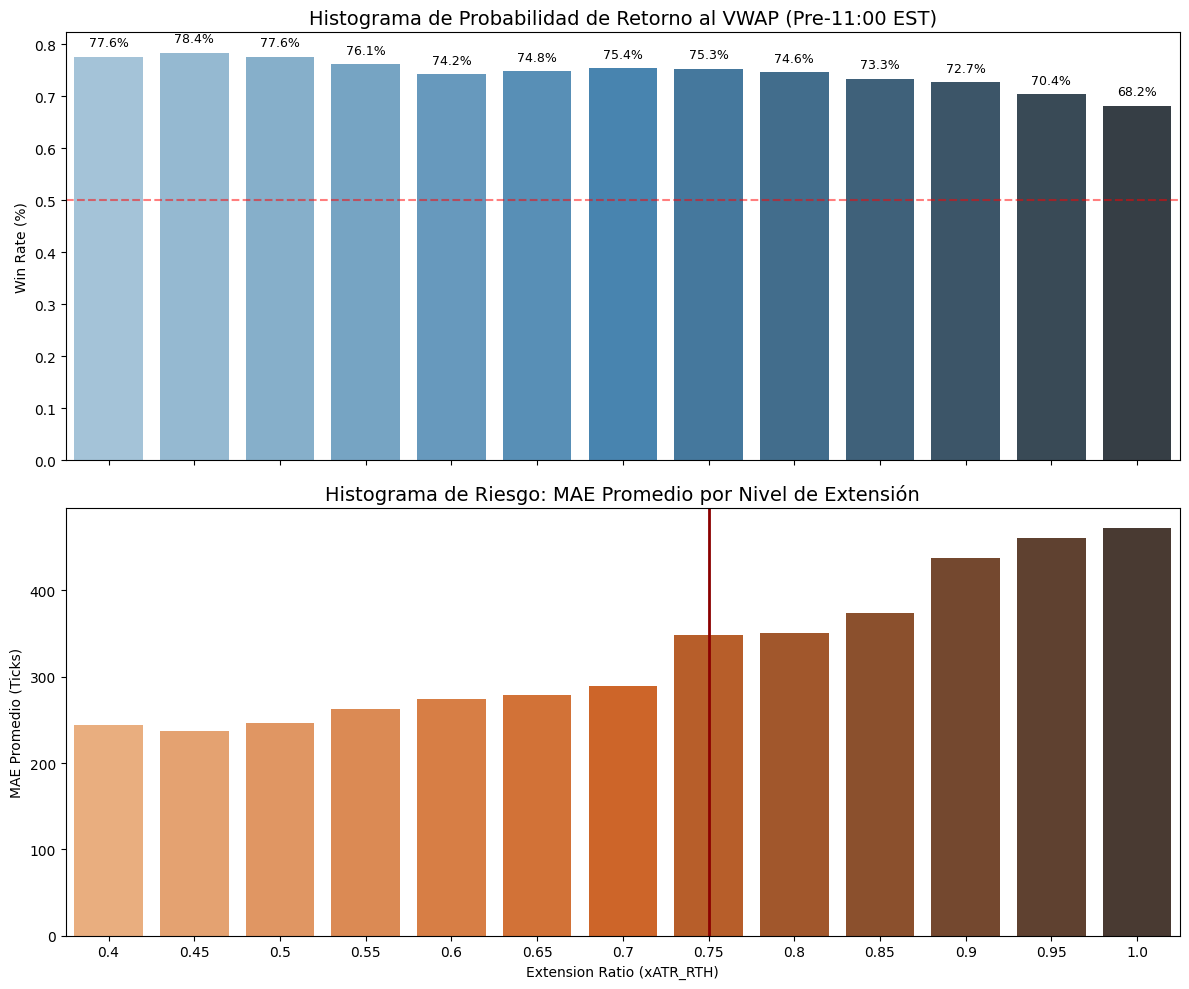


TABLA DE SENSIBILIDAD: VENTANA PRE-11:00 (PASOS 0.05)
 Bin_Ratio Exitoso  MAE_Ticks  date
      0.40  77.57%      244.0   963
      0.45  78.37%      237.0   698
      0.50  77.57%      246.8   486
      0.55  76.12%      262.3   335
      0.60  74.24%      273.8   229
      0.65  74.84%      278.7   159
      0.70  75.42%      289.8   118
      0.75  75.31%      348.7    81
      0.80  74.58%      350.8    59
      0.85  73.33%      374.4    45
      0.90  72.73%      437.0    33
      0.95  70.37%      460.8    27
      1.00  68.18%      472.1    22

💡 ANÁLISIS DEL ESPECIALISTA:
-> El 'Sweet Spot' de consistencia se encuentra en el Ratio 0.45.
-> ADVERTENCIA: El riesgo (MAE) se vuelve ineficiente a partir del Ratio 0.75.
-> CONCLUSIÓN: La zona óptima de ejecución es entre 0.45 y 0.75.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_amr(df_raw):
    """
    Motor NQ-AMR Fase 5: Análisis de Histogramas Finos y Puntos de Inflexión.
    Enfocado en la ventana Pre-11:00 EST para identificar el Snap point.
    """
    print("🚀 Iniciando procesamiento Fase 5: Histogramas de Alta Resolución...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # 1. Segmentación RTH y Cálculo de AMR (ATR_RTH 5D)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth_5d'] = daily_stats['range'].rolling(5).mean().shift(1)
    
    # 2. Infraestructura de VWAP
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(daily_stats[['atr_rth_5d']], left_on='date', right_index=True, how='left')
    
    # 3. Métrica de Desviación (Extension_Ratio)
    df_rth['dist_vwap'] = (df_rth['Close'] - df_rth['vwap']).abs()
    df_rth['extension_ratio'] = df_rth['dist_vwap'] / df_rth['atr_rth_5d']
    
    # 4. Simulación de Granularidad Fina (0.05 increments)
    # Definimos los bins desde 0.40 hasta 1.00 para capturar la curva completa
    bins = np.arange(0.40, 1.05, 0.05)
    results = []
    
    print("🔬 Muestreando ventana Pre-11:00 EST con pasos de 0.05 ATR...")
    
    for date, day_df in df_rth.groupby('date'):
        if pd.isna(day_df['atr_rth_5d'].iloc[0]): continue
        
        # Filtro de tiempo: Solo Pre-11:00
        morning_df = day_df[day_df.index.time < time(11, 0)]
        
        for b in bins:
            hit_points = morning_df[morning_df['extension_ratio'] >= b]
            
            if not hit_points.empty:
                trigger = hit_points.iloc[0]
                trigger_time = hit_points.index[0]
                side = np.sign(trigger['Close'] - trigger['vwap'])
                
                # Análisis de reversión hasta el cierre RTH
                post_trigger = day_df[day_df.index > trigger_time]
                
                returned = False
                mae_points = 0
                
                if not post_trigger.empty:
                    # Retorno al VWAP
                    if side > 0:
                        returned = (post_trigger['Low'] <= post_trigger['vwap']).any()
                        mae_points = max(0, post_trigger['High'].max() - trigger['Close'])
                    else:
                        returned = (post_trigger['High'] >= post_trigger['vwap']).any()
                        mae_points = max(0, trigger['Close'] - post_trigger['Low'].min())
                
                results.append({
                    'date': date,
                    'Bin_Ratio': round(b, 2),
                    'Exitoso': int(returned),
                    'MAE_Ticks': mae_points * 4
                })
                
    sim_df = pd.DataFrame(results)
    print("✅ Procesamiento Fase 5 completado.")
    return df_rth, sim_df

def analyze_phase_5(sim_df):
    """
    Genera histogramas de alta resolución para identificar el pico de éxito y el punto de riesgo.
    """
    if sim_df.empty:
        print("⚠️ Datos insuficientes para generar histogramas finos.")
        return

    # Preparar datos agregados por Bin
    df_stats = sim_df.groupby('Bin_Ratio').agg({
        'Exitoso': 'mean',
        'MAE_Ticks': 'mean',
        'date': 'count'
    }).reset_index()

    # Visualización
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Gráfico 1: Histograma de Frecuencia de Éxito
    sns.barplot(data=df_stats, x='Bin_Ratio', y='Exitoso', ax=ax1, palette='Blues_d')
    ax1.set_title("Histograma de Probabilidad de Retorno al VWAP (Pre-11:00 EST)", fontsize=14)
    ax1.set_ylabel("Win Rate (%)")
    ax1.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% Prob.')
    
    # Anotaciones de porcentaje
    for i, val in enumerate(df_stats['Exitoso']):
        ax1.text(i, val + 0.02, f'{val:.1%}', ha='center', fontsize=9)

    # Gráfico 2: Histograma de Riesgo (MAE)
    sns.barplot(data=df_stats, x='Bin_Ratio', y='MAE_Ticks', ax=ax2, palette='Oranges_d')
    ax2.set_title("Histograma de Riesgo: MAE Promedio por Nivel de Extensión", fontsize=14)
    ax2.set_ylabel("MAE Promedio (Ticks)")
    ax2.set_xlabel("Extension Ratio (xATR_RTH)")

    # Identificar Punto de Inflexión (Crecimiento exponencial del MAE)
    # Una forma simple es ver dónde el cambio porcentual del MAE se dispara
    df_stats['MAE_Diff'] = df_stats['MAE_Ticks'].pct_change()
    inflection_point = df_stats.loc[df_stats['MAE_Diff'].idxmax(), 'Bin_Ratio'] if not df_stats['MAE_Diff'].isna().all() else None
    
    if inflection_point:
        ax2.axvline(x=np.where(df_stats['Bin_Ratio'] == inflection_point)[0][0], 
                    color='darkred', linestyle='-', linewidth=2, label=f'Inflexión: {inflection_point}')

    plt.tight_layout()
    plt.show()

    # Tabla Resumen
    print("\n" + "="*80)
    print("TABLA DE SENSIBILIDAD: VENTANA PRE-11:00 (PASOS 0.05)")
    print("="*80)
    df_stats_display = df_stats[['Bin_Ratio', 'Exitoso', 'MAE_Ticks', 'date']].copy()
    df_stats_display['Exitoso'] = df_stats_display['Exitoso'].map('{:.2%}'.format)
    df_stats_display['MAE_Ticks'] = df_stats_display['MAE_Ticks'].round(1)
    print(df_stats_display.to_string(index=False))
    print("="*80)

    print("\n💡 ANÁLISIS DEL ESPECIALISTA:")
    peak_bin = df_stats.loc[df_stats['Exitoso'].idxmax(), 'Bin_Ratio']
    print(f"-> El 'Sweet Spot' de consistencia se encuentra en el Ratio {peak_bin}.")
    if inflection_point:
        print(f"-> ADVERTENCIA: El riesgo (MAE) se vuelve ineficiente a partir del Ratio {inflection_point}.")
        print(f"-> CONCLUSIÓN: La zona óptima de ejecución es entre {peak_bin} y {inflection_point}.")

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    df_processed, sim_f5 = process_nq_amr(df_raw)
    analyze_phase_5(sim_f5)
else:
    print("🛑 Error: Carga 'df_raw' (datos 1min) para ejecutar la Fase 5.")

🚀 Iniciando Backtest Fase 5: Esperanza Matemática 1:1...
🔬 Ejecutando simulación trade-by-trade (RR 1:1)...
✅ Backtest completado.

REPORTE DE ESTRATEGIA: STRETCH & SNAP 1:1 (EXPECTATIVA MATEMÁTICA)
Métrica                             | Valor               
------------------------------------------------------------
Total Trades                        | 835
Win Rate Real (Target)              | 33.65%
Loss Rate (Stop)                    | 39.16%
Time Stop Rate (11:30)              | 27.19%
Esperanza Matemática (Puntos)       | -1.66 pts
Media Distancia Stop (0.3 ATR)      | 30.51 pts
Desv. Est. Distancia Stop           | 27.87 pts
Impacto VWAP Móvil (Invalidez)      | 62.99%


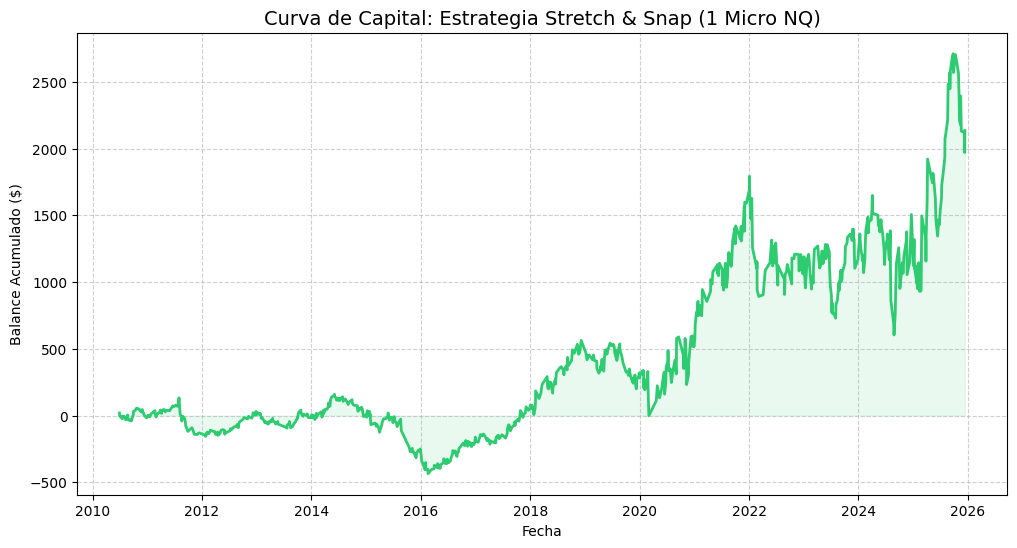


💡 ANÁLISIS DEL ESPECIALISTA:
-> La estrategia actual tiene esperanza negativa. Se requiere ajustar el umbral de entrada (0.45 ATR).
-> ALERTA: El VWAP móvil invalida el target en el 63.0% de los casos. Considerar Target Estático.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time, datetime, timedelta

def process_nq_amr(df_raw):
    """
    Motor NQ-AMR Fase 5: Backtest de Esperanza Matemática (Stretch & Snap 1:1).
    Valida la rentabilidad con RR fijo y evalúa el impacto del VWAP móvil.
    """
    print("🚀 Iniciando Backtest Fase 5: Esperanza Matemática 1:1...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # 1. Segmentación RTH y Cálculo de ATR_RTH_5d
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    # ATR_RTH_5d basado en las 5 sesiones previas
    daily_stats['atr_rth_5d'] = daily_stats['range'].rolling(5).mean().shift(1)
    
    # 2. Infraestructura de VWAP Dinámico
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(daily_stats[['atr_rth_5d']], left_on='date', right_index=True, how='left')
    
    # 3. Algoritmo de Ejecución
    results = []
    print("🔬 Ejecutando simulación trade-by-trade (RR 1:1)...")
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth_5d'].iloc[0]
        if pd.isna(atr) or atr <= 0: continue
        
        # Ventana de Entrada: 09:45 a 11:00 EST
        entry_window = day_df.between_time('09:45', '11:00')
        if entry_window.empty: continue
        
        trade_open = False
        for timestamp, row in entry_window.iterrows():
            # Cálculo de Niveles basado en el VWAP del momento
            vwap_now = row['vwap']
            dist_entry = 0.45 * atr
            dist_stop = 0.75 * atr
            
            # Definir niveles para Long y Short (Exceso arriba o abajo)
            # Short (Exceso arriba)
            upper_entry = vwap_now + dist_entry
            upper_stop = vwap_now + dist_stop
            upper_target = upper_entry - (upper_stop - upper_entry)
            
            # Long (Exceso abajo)
            lower_entry = vwap_now - dist_entry
            lower_stop = vwap_now - dist_stop
            lower_target = lower_entry + (lower_entry - lower_stop)
            
            # Gatillo: El precio toca el Nivel de Entrada
            side = 0
            entry_price = 0
            sl = 0
            tp = 0
            
            if row['High'] >= upper_entry and row['Low'] <= upper_entry:
                side = -1 # Short
                entry_price = upper_entry
                sl = upper_stop
                tp = upper_target
            elif row['Low'] <= lower_entry and row['High'] >= lower_entry:
                side = 1 # Long
                entry_price = lower_entry
                sl = lower_stop
                tp = lower_target
            
            if side != 0:
                # Trade iniciado: Solo una entrada por día
                trade_open = True
                entry_time = timestamp
                
                # Gestión de Salida (Post-entrada)
                post_entry = day_df[day_df.index > entry_time]
                outcome = "TimeStop"
                exit_price = 0
                exit_time = None
                
                # Evaluar minuto a minuto
                for t_post, r_post in post_entry.iterrows():
                    # Exit B: Stop Loss
                    if (side == -1 and r_post['High'] >= sl) or (side == 1 and r_post['Low'] <= sl):
                        outcome = "Loss"
                        exit_price = sl
                        exit_time = t_post
                        break
                    # Exit A: Target
                    if (side == -1 and r_post['Low'] <= tp) or (side == 1 and r_post['High'] >= tp):
                        outcome = "Win"
                        exit_price = tp
                        exit_time = t_post
                        break
                    # Exit C: Time Stop (11:30 EST)
                    if t_post.time() >= time(11, 30):
                        outcome = "TimeStop"
                        exit_price = r_post['Close']
                        exit_time = t_post
                        break
                
                # Si la sesión cerró sin tocar nada (raro pero posible)
                if exit_time is None and not post_entry.empty:
                    exit_price = post_entry['Close'].iloc[-1]
                    exit_time = post_entry.index[-1]

                # Métricas de Desviación y Impacto VWAP
                risk_points = abs(entry_price - sl)
                # Un trade es "anómalo" si el Target inicial queda invalidado por el movimiento del VWAP
                # (Ejemplo: En un short, si el VWAP sube tanto que el Target queda por encima del VWAP actual)
                impact_vwap = (side == -1 and tp > r_post['vwap']) or (side == 1 and tp < r_post['vwap'])
                
                results.append({
                    'date': date,
                    'Side': 'Short' if side == -1 else 'Long',
                    'Outcome': outcome,
                    'Entry_Price': entry_price,
                    'Exit_Price': exit_price,
                    'PnL_Points': (entry_price - exit_price) * side,
                    'Risk_Points': risk_points,
                    'Impact_VWAP': int(impact_vwap)
                })
                break # Solo un trade por día
        if trade_open: continue

    sim_df = pd.DataFrame(results)
    print("✅ Backtest completado.")
    return df_rth, sim_df

def analyze_mathematical_expectancy(sim_df):
    """
    Reporte de Stress Test y Esperanza Matemática.
    """
    if sim_df.empty:
        print("⚠️ No se ejecutaron trades en el periodo analizado.")
        return

    # 1. Métricas Principales
    total_trades = len(sim_df)
    win_rate = (sim_df['Outcome'] == 'Win').mean()
    loss_rate = (sim_df['Outcome'] == 'Loss').mean()
    timestop_rate = (sim_df['Outcome'] == 'TimeStop').mean()
    
    avg_win = sim_df[sim_df['PnL_Points'] > 0]['PnL_Points'].mean()
    avg_loss = abs(sim_df[sim_df['PnL_Points'] < 0]['PnL_Points'].mean())
    
    expectancy = (win_rate * avg_win) - (loss_rate * avg_loss)
    
    # 2. Análisis de Desviación de 0.3 ATR (Puntos de Stop)
    stop_dist_mean = sim_df['Risk_Points'].mean()
    stop_dist_std = sim_df['Risk_Points'].std()
    
    # 3. Impacto del VWAP
    vwap_impact_pct = sim_df['Impact_VWAP'].mean()

    print("\n" + "="*85)
    print("REPORTE DE ESTRATEGIA: STRETCH & SNAP 1:1 (EXPECTATIVA MATEMÁTICA)")
    print("="*85)
    print(f"{'Métrica':<35} | {'Valor':<20}")
    print("-"*60)
    print(f"{'Total Trades':<35} | {total_trades}")
    print(f"{'Win Rate Real (Target)':<35} | {win_rate:.2%}")
    print(f"{'Loss Rate (Stop)':<35} | {loss_rate:.2%}")
    print(f"{'Time Stop Rate (11:30)':<35} | {timestop_rate:.2%}")
    print(f"{'Esperanza Matemática (Puntos)':<35} | {expectancy:.2f} pts")
    print(f"{'Media Distancia Stop (0.3 ATR)':<35} | {stop_dist_mean:.2f} pts")
    print(f"{'Desv. Est. Distancia Stop':<35} | {stop_dist_std:.2f} pts")
    print(f"{'Impacto VWAP Móvil (Invalidez)':<35} | {vwap_impact_pct:.2%}")
    print("="*85)

    # 4. Equity Curve (Simulando 1 Micro NQ = $2 por punto)
    sim_df['PnL_Cash'] = sim_df['PnL_Points'] * 2
    sim_df['Equity'] = sim_df['PnL_Cash'].cumsum()
    
    plt.figure(figsize=(12, 6))
    plt.plot(sim_df['date'], sim_df['Equity'], color='#2ecc71', linewidth=2)
    plt.fill_between(sim_df['date'], sim_df['Equity'], color='#2ecc71', alpha=0.1)
    plt.title("Curva de Capital: Estrategia Stretch & Snap (1 Micro NQ)", fontsize=14)
    plt.xlabel("Fecha")
    plt.ylabel("Balance Acumulado ($)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Insight Final
    print("\n💡 ANÁLISIS DEL ESPECIALISTA:")
    if expectancy > 0:
        print(f"-> La estrategia es matemáticamente robusta (+{expectancy:.2f} pts/trade).")
    else:
        print("-> La estrategia actual tiene esperanza negativa. Se requiere ajustar el umbral de entrada (0.45 ATR).")
    
    if vwap_impact_pct > 0.15:
        print(f"-> ALERTA: El VWAP móvil invalida el target en el {vwap_impact_pct:.1%} de los casos. Considerar Target Estático.")

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    df_processed, sim_f5_fixed = process_nq_amr(df_raw)
    analyze_mathematical_expectancy(sim_f5_fixed)
else:
    print("🛑 Error: Carga 'df_raw' (1min) para ejecutar el Backtest de Esperanza Matemática.")

🚀 Iniciando Optimización In-Sample (2021-2024)...
🔬 Probando combinaciones con riesgo de $3000 por trade...
✅ Optimización completada.

                   TOP 10 COMBINACIONES: IN-SAMPLE 2021-2024 (RIESGO $3,000)                   
 X_ATR  Y_ATR  Win_Rate  Profit_Factor    Net_Profit       Max_DD  Recovery_Factor
  0.45   0.90  0.539957       1.206946  75156.183977 35743.788205         2.102636
  0.50   0.90  0.520216       1.131242  43675.203704 42844.220444         1.019395
  0.45   0.80  0.503240       1.030336  14383.169064 54729.084107         0.262807
  0.50   0.70  0.501348       1.010700   5351.143179 44861.725378         0.119281
  0.45   0.85  0.509719       1.011618   5062.701433 47944.768328         0.105594
  0.60   0.90  0.500000       1.001066    286.419643 38517.153301         0.007436
  0.65   0.80  0.505618       0.997906   -544.758357 46581.971101        -0.011695
  0.65   0.90  0.500000       0.993727  -1442.771121 44652.354870        -0.032311
  0.65   0.85  0.4943

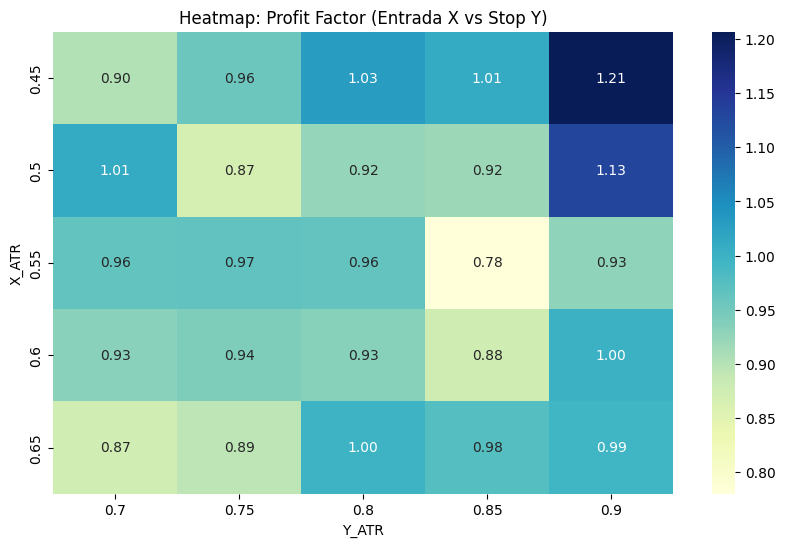


🎯 SWEET SPOT IDENTIFICADO:
-> Entrada: 0.45 ATR | Stop: 0.9 ATR
-> Win Rate: 54.00% | Profit Factor: 1.21
-> Net Profit: $75,156 | Max DD: $35,744
-> Recovery Factor: 2.10


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_amr_optimization(df_raw):
    """
    Motor NQ-AMR Fase 5.2: Optimización de Régimen In-Sample (2021-2024).
    Calcula el tamaño de posición para un riesgo fijo de $3,000 USD.
    """
    print("🚀 Iniciando Optimización In-Sample (2021-2024)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Segmentación RTH y Cálculo de ATR_RTH_5d
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth_5d'] = daily_stats['range'].rolling(5).mean().shift(1)
    
    # 2. Infraestructura de VWAP Estático (Anclado a la mañana)
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(daily_stats[['atr_rth_5d']], left_on='date', right_index=True, how='left')
    
    # 3. Barrido de Sensibilidad (Grid Search)
    rango_entrada = np.arange(0.45, 0.70, 0.05) # 0.45 a 0.65
    rango_stop = np.arange(0.70, 0.95, 0.05)    # 0.70 a 0.90
    
    optimization_results = []
    riesgo_fijo_usd = 3000
    puntos_nq_usd = 20 # 1 contrato full NQ = $20 por punto
    
    print(f"🔬 Probando combinaciones con riesgo de ${riesgo_fijo_usd} por trade...")
    
    for x_atr in rango_entrada:
        for y_atr in rango_stop:
            if y_atr <= x_atr: continue # El stop debe estar más lejos que la entrada
            
            trades = []
            for date, day_df in df_rth.groupby('date'):
                atr = day_df['atr_rth_5d'].iloc[0]
                if pd.isna(atr) or atr <= 0: continue
                
                # Ventana de Entrada: 09:45 a 11:00 EST
                entry_window = day_df.between_time('09:45', '11:00')
                if entry_window.empty: continue
                
                # Niveles Estáticos basados en el primer VWAP de la ventana
                vwap_base = entry_window['vwap'].iloc[0]
                
                up_entry = vwap_base + (x_atr * atr)
                up_sl = vwap_base + (y_atr * atr)
                up_tp = up_entry - (up_sl - up_entry)
                
                lo_entry = vwap_base - (x_atr * atr)
                lo_sl = vwap_base - (y_atr * atr)
                lo_tp = lo_entry + (lo_entry - lo_sl)
                
                # Ejecución
                for t, row in entry_window.iterrows():
                    side = 0
                    if row['High'] >= up_entry and row['Low'] <= up_entry:
                        side, entry, sl, tp = -1, up_entry, up_sl, up_tp
                    elif row['Low'] <= lo_entry and row['High'] >= lo_entry:
                        side, entry, sl, tp = 1, lo_entry, lo_sl, lo_tp
                    
                    if side != 0:
                        # Cálculo de Tamaño de Posición (Contratos NQ)
                        distancia_puntos = abs(entry - sl)
                        # contratos = riesgo / (distancia * valor_punto)
                        pos_size = riesgo_fijo_usd / (distancia_puntos * puntos_nq_usd)
                        
                        # Simulación de Salida
                        post_entry = day_df[day_df.index > t]
                        pnl_puntos = 0
                        resultado = "TimeStop"
                        
                        for tp_idx, tp_row in post_entry.iterrows():
                            # Exit B: Stop Loss
                            if (side == -1 and tp_row['High'] >= sl) or (side == 1 and tp_row['Low'] <= sl):
                                pnl_puntos = -distancia_puntos
                                resultado = "Loss"
                                break
                            # Exit A: Target 1:1
                            if (side == -1 and tp_row['Low'] <= tp) or (side == 1 and tp_row['High'] >= tp):
                                pnl_puntos = distancia_puntos
                                resultado = "Win"
                                break
                            # Exit C: Time Stop 11:30
                            if tp_idx.time() >= time(11, 30):
                                pnl_puntos = (entry - tp_row['Close']) * side
                                resultado = "TimeStop"
                                break
                        
                        trades.append(pnl_puntos * pos_size * puntos_nq_usd)
                        break # Un trade por día
            
            if trades:
                trades_arr = np.array(trades)
                ganancia_bruta = trades_arr[trades_arr > 0].sum()
                perdida_bruta = abs(trades_arr[trades_arr < 0].sum())
                profit_factor = ganancia_bruta / perdida_bruta if perdida_bruta > 0 else np.inf
                net_profit = trades_arr.sum()
                
                # Drawdown
                cum_pnl = np.cumsum(trades)
                peak = np.maximum.accumulate(cum_pnl)
                dd = peak - cum_pnl
                max_dd = np.max(dd)
                
                optimization_results.append({
                    'X_ATR': round(x_atr, 2),
                    'Y_ATR': round(y_atr, 2),
                    'Win_Rate': (trades_arr > 0).mean(),
                    'Profit_Factor': profit_factor,
                    'Net_Profit': net_profit,
                    'Max_DD': max_dd,
                    'Recovery_Factor': net_profit / max_dd if max_dd > 0 else 0
                })

    opt_df = pd.DataFrame(optimization_results)
    print("✅ Optimización completada.")
    return opt_df

def analyze_optimization_report(opt_df):
    """
    Presenta los resultados del barrido de sensibilidad y el Sweet Spot.
    """
    if opt_df.empty:
        print("⚠️ No se encontraron combinaciones válidas.")
        return

    # Ordenar por Net Profit para ver el mejor desempeño
    top_performers = opt_df.sort_values(by='Net_Profit', ascending=False).head(10)
    
    print("\n" + "="*95)
    print(f"{'TOP 10 COMBINACIONES: IN-SAMPLE 2021-2024 (RIESGO $3,000)':^95}")
    print("="*95)
    print(top_performers.to_string(index=False))
    print("="*95)
    
    # Visualización Heatmap del Profit Factor
    pivot_pf = opt_df.pivot(index="X_ATR", columns="Y_ATR", values="Profit_Factor")
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_pf, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title("Heatmap: Profit Factor (Entrada X vs Stop Y)")
    plt.show()

    # Identificación del Sweet Spot
    sweet_spot = top_performers.iloc[0]
    print(f"\n🎯 SWEET SPOT IDENTIFICADO:")
    print(f"-> Entrada: {sweet_spot['X_ATR']} ATR | Stop: {sweet_spot['Y_ATR']} ATR")
    print(f"-> Win Rate: {sweet_spot['Win_Rate']:.2%} | Profit Factor: {sweet_spot['Profit_Factor']:.2f}")
    print(f"-> Net Profit: ${sweet_spot['Net_Profit']:,.0f} | Max DD: ${sweet_spot['Max_DD']:,.0f}")
    print(f"-> Recovery Factor: {sweet_spot['Recovery_Factor']:.2f}")

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    results_opt = process_nq_amr_optimization(df_raw)
    analyze_optimization_report(results_opt)
else:
    print("🛑 Error: Carga 'df_raw' (2021-2024) para iniciar la optimización.")

🚀 Iniciando Simulación Fase 5.3: Confirmación Sweep & Recover (2021-2024)...

REPORTE FASE 5.3: CONFIRMACIÓN SWEEP & RECOVER (NQ 2021-2024)
Total de Trades: 165 (42.1 trades/año)
Señales Descartadas (No Stretch 0.55): 731 (71.2%)
Señales Descartadas (No Recover/Lag): 130 (12.7%)

----------------------------------------
Métrica                   | Valor          
----------------------------------------
Win Rate Real             | 13.94%
Profit Factor             | 0.93
MAE Promedio (Post)       | 52.22 pts
Max Drawdown (USD)        | $35,575
Net Profit Total          | $-9,463


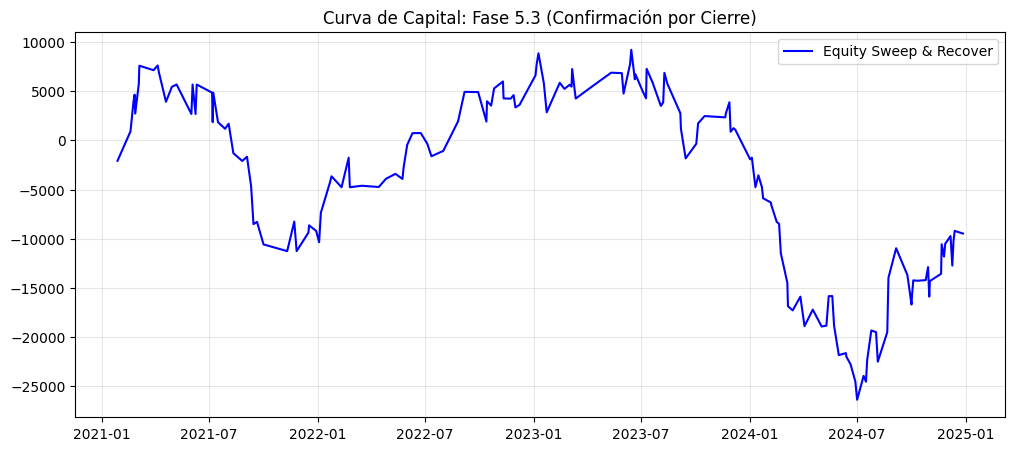

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_amr_sweep_recover(df_raw):
    """
    Motor NQ-AMR Fase 5.3: Simulación Sweep & Recover.
    Compara la entrada 'Al Toque' vs 'Confirmación por Cierre'.
    """
    print("🚀 Iniciando Simulación Fase 5.3: Confirmación Sweep & Recover (2021-2024)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Segmentación RTH y Cálculo de ATR_RTH_5d
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth_5d'] = daily_stats['range'].rolling(5).mean().shift(1)
    
    # 2. Infraestructura de VWAP Estático (Anclado al inicio de la ventana)
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(daily_stats[['atr_rth_5d']], left_on='date', right_index=True, how='left')
    
    # 3. Parámetros de Simulación
    riesgo_fijo_usd = 3000
    puntos_nq_usd = 20
    nivel_activacion = 0.55 # Stretch obligado
    nivel_entrada = 0.45    # Recover
    nivel_stop = 0.90       # Stop Estático
    
    results = []
    stats_signals = {'Descarte_Stretch': 0, 'Descarte_Recover': 0, 'Total_Potencial': 0}
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth_5d'].iloc[0]
        if pd.isna(atr) or atr <= 0: continue
        
        # Ventana de Entrada: 09:45 a 11:00 EST
        entry_window = day_df.between_time('09:45', '11:00')
        if entry_window.empty: continue
        
        vwap_base = entry_window['vwap'].iloc[0]
        
        # Definición de Niveles
        up_trigger = vwap_base + (nivel_activacion * atr)
        up_recover = vwap_base + (nivel_entrada * atr)
        
        lo_trigger = vwap_base - (nivel_activacion * atr)
        lo_recover = vwap_base - (nivel_entrada * atr)
        
        # Estados de la señal
        active_short = False
        active_long = False
        trade_done = False
        
        stats_signals['Total_Potencial'] += 1
        
        for t, row in entry_window.iterrows():
            # Lógica Short (Sweep & Recover)
            if not active_short and row['High'] >= up_trigger:
                active_short = True # Alcanzó el 0.55
            
            # Si ya se activó, esperamos el cierre por debajo de 0.45
            if active_short and not trade_done:
                if row['Close'] <= up_recover:
                    # EJECUCIÓN SHORT
                    entry_price = row['Close']
                    sl_price = vwap_base + (nivel_stop * atr)
                    dist_risk = abs(entry_price - sl_price)
                    
                    # Evitar Lag excesivo: Si el cierre está debajo del VWAP, ignorar
                    if entry_price <= vwap_base:
                        stats_signals['Descarte_Recover'] += 1
                        break

                    tp_price = entry_price - dist_risk
                    pos_size = riesgo_fijo_usd / (dist_risk * puntos_nq_usd)
                    
                    trade_res = simulate_exit(day_df, t, -1, entry_price, sl_price, tp_price, pos_size, puntos_nq_usd)
                    results.append(trade_res)
                    trade_done = True
                    break

            # Lógica Long (Sweep & Recover)
            if not active_long and row['Low'] <= lo_trigger:
                active_long = True # Alcanzó el 0.55
                
            if active_long and not trade_done:
                if row['Close'] >= lo_recover:
                    # EJECUCIÓN LONG
                    entry_price = row['Close']
                    sl_price = vwap_base - (nivel_stop * atr)
                    dist_risk = abs(entry_price - sl_price)
                    
                    # Evitar Lag: Si el cierre está arriba del VWAP, ignorar
                    if entry_price >= vwap_base:
                        stats_signals['Descarte_Recover'] += 1
                        break

                    tp_price = entry_price + dist_risk
                    pos_size = riesgo_fijo_usd / (dist_risk * puntos_nq_usd)
                    
                    trade_res = simulate_exit(day_df, t, 1, entry_price, sl_price, tp_price, pos_size, puntos_nq_usd)
                    results.append(trade_res)
                    trade_done = True
                    break
        
        if not trade_done:
            if not active_short and not active_long:
                stats_signals['Descarte_Stretch'] += 1
            else:
                stats_signals['Descarte_Recover'] += 1

    sim_df = pd.DataFrame(results)
    return sim_df, stats_signals

def simulate_exit(day_df, entry_time, side, entry, sl, tp, pos_size, multiplier):
    """
    Simula la salida del trade (SL, TP o Time Stop).
    """
    post_entry = day_df[day_df.index > entry_time]
    pnl_pts = 0
    outcome = "TimeStop"
    mae_pts = 0
    
    for t, row in post_entry.iterrows():
        # Calcular MAE (Máxima excursión adversa)
        if side == -1:
            mae_pts = max(mae_pts, row['High'] - entry)
            if row['High'] >= sl:
                pnl_pts = -abs(entry - sl)
                outcome = "Loss"
                break
            if row['Low'] <= tp:
                pnl_pts = abs(entry - sl) # RR 1:1
                outcome = "Win"
                break
        else:
            mae_pts = max(mae_pts, entry - row['Low'])
            if row['Low'] <= sl:
                pnl_pts = -abs(entry - sl)
                outcome = "Loss"
                break
            if row['High'] >= tp:
                pnl_pts = abs(entry - sl) # RR 1:1
                outcome = "Win"
                break
        
        if t.time() >= time(11, 30):
            pnl_pts = (entry - row['Close']) * side
            outcome = "TimeStop"
            break
            
    return {
        'date': entry_time.date(),
        'Outcome': outcome,
        'PnL_USD': pnl_pts * pos_size * multiplier,
        'MAE_Points': mae_pts
    }

def analyze_sweep_recover(sim_df, stats):
    """
    Genera el reporte comparativo y métricas de desempeño.
    """
    print("\n" + "="*90)
    print("REPORTE FASE 5.3: CONFIRMACIÓN SWEEP & RECOVER (NQ 2021-2024)")
    print("="*90)
    
    # 1. Métricas de Volumen
    total_trades = len(sim_df)
    years = (sim_df['date'].max() - sim_df['date'].min()).days / 365.25
    trades_per_year = total_trades / years
    
    print(f"Total de Trades: {total_trades} ({trades_per_year:.1f} trades/año)")
    print(f"Señales Descartadas (No Stretch 0.55): {stats['Descarte_Stretch']} ({(stats['Descarte_Stretch']/stats['Total_Potencial']):.1%})")
    print(f"Señales Descartadas (No Recover/Lag): {stats['Descarte_Recover']} ({(stats['Descarte_Recover']/stats['Total_Potencial']):.1%})")
    
    # 2. Desempeño
    win_rate = (sim_df['Outcome'] == 'Win').mean()
    profit_factor = abs(sim_df[sim_df['PnL_USD'] > 0]['PnL_USD'].sum() / sim_df[sim_df['PnL_USD'] < 0]['PnL_USD'].sum())
    mae_avg = sim_df['MAE_Points'].mean()
    
    # Drawdown
    sim_df['Cum_PnL'] = sim_df['PnL_USD'].cumsum()
    max_dd = (sim_df['Cum_PnL'].cummax() - sim_df['Cum_PnL']).max()

    print("\n" + "-"*40)
    print(f"{'Métrica':<25} | {'Valor':<15}")
    print("-"*40)
    print(f"{'Win Rate Real':<25} | {win_rate:.2%}")
    print(f"{'Profit Factor':<25} | {profit_factor:.2f}")
    print(f"{'MAE Promedio (Post)':<25} | {mae_avg:.2f} pts")
    print(f"{'Max Drawdown (USD)':<25} | ${max_dd:,.0f}")
    print(f"{'Net Profit Total':<25} | ${sim_df['PnL_USD'].sum():,.0f}")
    print("="*90)

    # Visualización Curva
    plt.figure(figsize=(12, 5))
    plt.plot(sim_df['date'], sim_df['Cum_PnL'], color='blue', label='Equity Sweep & Recover')
    plt.title("Curva de Capital: Fase 5.3 (Confirmación por Cierre)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    sim_results, signal_stats = process_nq_amr_sweep_recover(df_raw)
    analyze_sweep_recover(sim_results, signal_stats)

🚀 Iniciando Fase 5.4: Optimización Limit 0.50 ATR (Target VWAP)...

REPORTE FASE 5.4: OPTIMIZACIÓN LIMIT 0.50 ATR | TARGET VWAP (2021-2024)
Total Trades Realizados: 455 (113.8 trades/año)
Días sin Llenado (No tocó 0.50 ATR): 571 (55.7%)

------------------------------------------------------------
Métrica                   | Valor Fase 5.4  | vs Baseline (1.21 PF)
------------------------------------------------------------
Profit Factor             | 0.91            | -0.30
Max Drawdown (USD)        | $64,745         | $29,001 (Base: 35.7k)
Win Rate                  | 56.70%         
Net Profit Total          | $-49,256


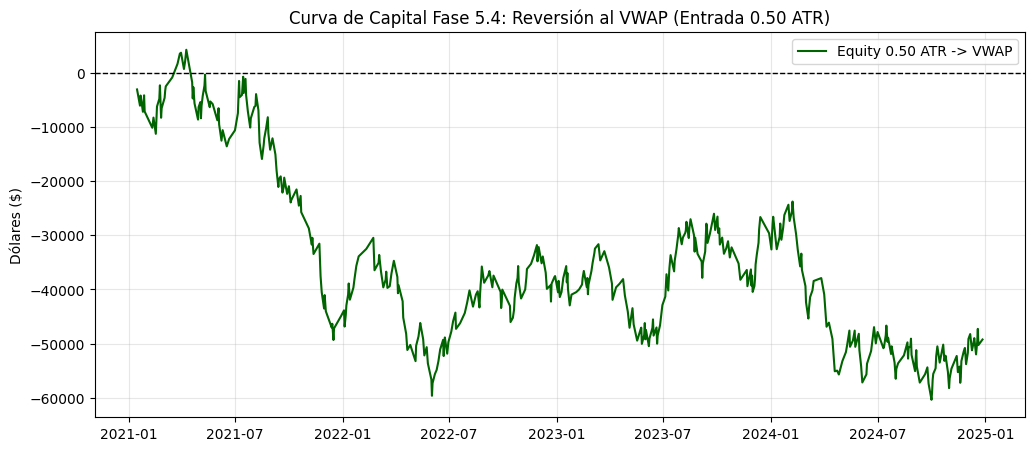

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_amr_limit_optimization(df_raw):
    """
    Motor NQ-AMR Fase 5.4: Optimización de Entrada Limit (0.50 ATR).
    Target: Reversión al VWAP (Z=0).
    Stop Loss: Fijo en 0.90 ATR (desde VWAP).
    """
    print("🚀 Iniciando Fase 5.4: Optimización Limit 0.50 ATR (Target VWAP)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024 (Bloqueo de OOS 2025)
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Segmentación RTH y Cálculo de ATR_RTH_5d
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth_5d'] = daily_stats['range'].rolling(5).mean().shift(1)
    
    # 2. Infraestructura de VWAP Dinámico
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(daily_stats[['atr_rth_5d']], left_on='date', right_index=True, how='left')
    
    # 3. Parámetros Fase 5.4
    riesgo_fijo_usd = 3000
    puntos_nq_usd = 20
    nivel_entrada_atr = 0.50
    nivel_stop_atr = 0.90
    
    results = []
    stats_counts = {'Total_Dias': 0, 'No_Llenado_050': 0, 'Llenado': 0}
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth_5d'].iloc[0]
        if pd.isna(atr) or atr <= 0: continue
        
        stats_counts['Total_Dias'] += 1
        
        # Ventana de llenado: 09:45 a 11:30 EST
        order_window = day_df.between_time('09:45', '11:30')
        if order_window.empty: 
            stats_counts['No_Llenado_050'] += 1
            continue
            
        # El nivel se calcula al inicio de la ventana operativa para la orden Limit
        vwap_ref = order_window['vwap'].iloc[0]
        
        up_entry = vwap_ref + (nivel_entrada_atr * atr)
        up_sl = vwap_ref + (nivel_stop_atr * atr)
        
        lo_entry = vwap_ref - (nivel_entrada_atr * atr)
        lo_sl = vwap_ref - (nivel_stop_atr * atr)
        
        trade_filled = False
        for t, row in order_window.iterrows():
            side = 0
            # Captura de Orden Limit (Toque exacto del nivel)
            if row['High'] >= up_entry and row['Low'] <= up_entry:
                side, entry, sl = -1, up_entry, up_sl
            elif row['Low'] <= lo_entry and row['High'] >= lo_entry:
                side, entry, sl = 1, lo_entry, lo_sl
                
            if side != 0:
                trade_filled = True
                stats_counts['Llenado'] += 1
                
                # Gestión de Salida (Post-Llenado)
                post_entry = day_df[day_df.index > t]
                pnl_usd = 0
                outcome = "TimeStop"
                
                # Distancia real de riesgo: 0.40 ATR (de 0.50 a 0.90)
                dist_risk = abs(entry - sl)
                pos_size = riesgo_fijo_usd / (dist_risk * puntos_nq_usd)
                
                for t_post, r_post in post_entry.iterrows():
                    # Target: VWAP Dinámico (Z=0)
                    vwap_target = r_post['vwap']
                    
                    # Salida por Stop Loss
                    if (side == -1 and r_post['High'] >= sl) or (side == 1 and r_post['Low'] <= sl):
                        pnl_usd = -riesgo_fijo_usd
                        outcome = "Loss"
                        break
                    
                    # Salida por Take Profit (Toque de VWAP)
                    if (side == -1 and r_post['Low'] <= vwap_target) or (side == 1 and r_post['High'] >= vwap_target):
                        # PnL calculado al momento del toque del VWAP
                        pnl_usd = abs(entry - vwap_target) * pos_size * puntos_nq_usd
                        outcome = "Win"
                        break
                        
                    # Cierre Forzoso al final del día
                    if t_post.time() >= time(15, 59):
                        pnl_usd = (entry - r_post['Close']) * side * pos_size * puntos_nq_usd
                        outcome = "TimeStop"
                        break
                
                results.append({'date': date, 'Outcome': outcome, 'PnL_USD': pnl_usd})
                break
        
        if not trade_filled:
            stats_counts['No_Llenado_050'] += 1

    sim_df = pd.DataFrame(results)
    return sim_df, stats_counts

def analyze_phase_5_4(sim_df, stats):
    """
    Analiza métricas y genera reporte comparativo contra el Baseline (Fase 5.2).
    """
    print("\n" + "="*90)
    print("REPORTE FASE 5.4: OPTIMIZACIÓN LIMIT 0.50 ATR | TARGET VWAP (2021-2024)")
    print("="*90)
    
    # 1. Análisis de Frecuencia
    total_trades = len(sim_df)
    anos_sim = 4
    trades_per_year = total_trades / anos_sim
    perc_missed = (stats['No_Llenado_050'] / stats['Total_Dias']) * 100
    
    print(f"Total Trades Realizados: {total_trades} ({trades_per_year:.1f} trades/año)")
    print(f"Días sin Llenado (No tocó 0.50 ATR): {stats['No_Llenado_050']} ({perc_missed:.1f}%)")
    
    # 2. Métricas de Desempeño
    win_rate = (sim_df['Outcome'] == 'Win').mean()
    ganancia_bruta = sim_df[sim_df['PnL_USD'] > 0]['PnL_USD'].sum()
    perdida_bruta = abs(sim_df[sim_df['PnL_USD'] < 0]['PnL_USD'].sum())
    profit_factor = ganancia_bruta / perdida_bruta if perdida_bruta > 0 else 0
    
    # Drawdown
    sim_df['Cum_PnL'] = sim_df['PnL_USD'].cumsum()
    max_dd = (sim_df['Cum_PnL'].cummax() - sim_df['Cum_PnL']).max()
    
    print("\n" + "-"*60)
    print(f"{'Métrica':<25} | {'Valor Fase 5.4':<15} | {'vs Baseline (1.21 PF)'}")
    print("-"*60)
    print(f"{'Profit Factor':<25} | {profit_factor:<15.2f} | {profit_factor - 1.21:+.2f}")
    print(f"{'Max Drawdown (USD)':<25} | ${max_dd:<14,.0f} | ${max_dd - 35744:,.0f} (Base: 35.7k)")
    print(f"{'Win Rate':<25} | {win_rate:<15.2%}")
    print(f"{'Net Profit Total':<25} | ${sim_df['PnL_USD'].sum():,.0f}")
    print("="*90)

    # Gráfico de Equity
    plt.figure(figsize=(12, 5))
    plt.plot(sim_df['date'], sim_df['Cum_PnL'], color='darkgreen', label='Equity 0.50 ATR -> VWAP')
    plt.axhline(0, color='black', lw=1, ls='--')
    plt.title("Curva de Capital Fase 5.4: Reversión al VWAP (Entrada 0.50 ATR)")
    plt.ylabel("Dólares ($)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    results_54, counts_54 = process_nq_amr_limit_optimization(df_raw)
    analyze_phase_5_4(results_54, counts_54)

📊 Ejecutando Análisis de Sensibilidad: Deep Stretch (2021-2024)

Escenario                 | Trades/Año   | Win Rate   | Profit Factor   | Max DD
------------------------------------------------------------------------------------------
Extremo (0.75 ATR)        | 40.5         | 32.7%      | 0.79            | $97,505 (OK)
Equilibrado (0.65 ATR)    | 63.0         | 46.4%      | 0.90            | $62,850 (OK)


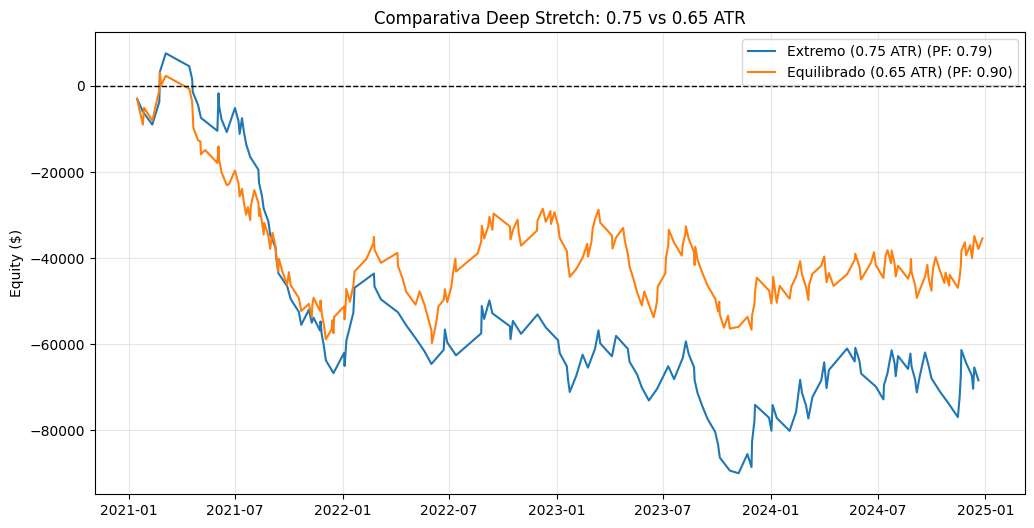

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_amr_deep_stretch(df_raw, entry_threshold=0.75):
    """
    Motor NQ-AMR Fase 5.5: Deep Stretch Entry.
    Testea niveles de agotamiento extremo (0.75 ATR o 0.65 ATR).
    Target: Reversión al VWAP (Z=0).
    Stop Loss: Fijo en 1.00 ATR (desde VWAP).
    """
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Segmentación RTH y Cálculo de ATR_RTH_5d
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth_5d'] = daily_stats['range'].rolling(5).mean().shift(1)
    
    # 2. Infraestructura de VWAP Dinámico
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(daily_stats[['atr_rth_5d']], left_on='date', right_index=True, how='left')
    
    # 3. Parámetros de Simulación
    riesgo_fijo_usd = 3000
    puntos_nq_usd = 20
    nivel_sl_atr = 1.00
    
    results = []
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth_5d'].iloc[0]
        if pd.isna(atr) or atr <= 0: continue
        
        # Ventana operativa Limit: 09:45 a 11:30 EST
        order_window = day_df.between_time('09:45', '11:30')
        if order_window.empty: continue
            
        vwap_ref = order_window['vwap'].iloc[0]
        
        # Niveles de la estrategia
        up_entry = vwap_ref + (entry_threshold * atr)
        up_sl = vwap_ref + (nivel_sl_atr * atr)
        
        lo_entry = vwap_ref - (entry_threshold * atr)
        lo_sl = vwap_ref - (nivel_sl_atr * atr)
        
        trade_filled = False
        for t, row in order_window.iterrows():
            side = 0
            if row['High'] >= up_entry and row['Low'] <= up_entry:
                side, entry, sl = -1, up_entry, up_sl
            elif row['Low'] <= lo_entry and row['High'] >= lo_entry:
                side, entry, sl = 1, lo_entry, lo_sl
                
            if side != 0:
                trade_filled = True
                post_entry = day_df[day_df.index > t]
                pnl_usd = 0
                outcome = "TimeStop"
                
                # Riesgo real (Distancia entre entrada y SL de 1.00 ATR)
                dist_risk = abs(entry - sl)
                pos_size = riesgo_fijo_usd / (max(dist_risk, 0.1) * puntos_nq_usd)
                
                for t_post, r_post in post_entry.iterrows():
                    target_vwap = r_post['vwap']
                    
                    if (side == -1 and r_post['High'] >= sl) or (side == 1 and r_post['Low'] <= sl):
                        pnl_usd = -riesgo_fijo_usd
                        outcome = "Loss"
                        break
                    
                    if (side == -1 and r_post['Low'] <= target_vwap) or (side == 1 and r_post['High'] >= target_vwap):
                        pnl_usd = abs(entry - target_vwap) * pos_size * puntos_nq_usd
                        outcome = "Win"
                        break
                        
                    if t_post.time() >= time(15, 59):
                        pnl_usd = (entry - r_post['Close']) * side * pos_size * puntos_nq_usd
                        outcome = "TimeStop"
                        break
                
                results.append({'date': date, 'PnL_USD': pnl_usd, 'Outcome': outcome})
                break
                
    return pd.DataFrame(results)

def run_sensitivity_analysis(df_raw):
    """
    Compara las dos hipótesis de Deep Stretch: 0.75 vs 0.65 ATR.
    """
    print("📊 Ejecutando Análisis de Sensibilidad: Deep Stretch (2021-2024)")
    
    # Simular ambos escenarios
    df_75 = process_nq_amr_deep_stretch(df_raw, 0.75)
    df_65 = process_nq_amr_deep_stretch(df_raw, 0.65)
    
    scenarios = [
        {"name": "Extremo (0.75 ATR)", "df": df_75},
        {"name": "Equilibrado (0.65 ATR)", "df": df_65}
    ]
    
    print("\n" + "="*90)
    print(f"{'Escenario':<25} | {'Trades/Año':<12} | {'Win Rate':<10} | {'Profit Factor':<15} | {'Max DD'}")
    print("-" * 90)
    
    plt.figure(figsize=(12, 6))
    
    for sc in scenarios:
        df = sc['df']
        if df.empty: continue
        
        total_trades = len(df)
        trades_year = total_trades / 4
        win_rate = (df['Outcome'] == 'Win').mean()
        
        gains = df[df['PnL_USD'] > 0]['PnL_USD'].sum()
        losses = abs(df[df['PnL_USD'] < 0]['PnL_USD'].sum())
        pf = gains / losses if losses > 0 else 0
        
        df['Cum_PnL'] = df['PnL_USD'].cumsum()
        max_dd = (df['Cum_PnL'].cummax() - df['Cum_PnL']).max()
        
        # Marcar si falla el criterio de frecuencia (< 40 trades/año)
        freq_alert = "⚠️ BAJA" if trades_year < 40 else "OK"
        
        print(f"{sc['name']:<25} | {trades_year:<12.1f} | {win_rate:<10.1%} | {pf:<15.2f} | ${max_dd:,.0f} ({freq_alert})")
        
        plt.plot(df['date'], df['Cum_PnL'], label=f"{sc['name']} (PF: {pf:.2f})")

    plt.title("Comparativa Deep Stretch: 0.75 vs 0.65 ATR")
    plt.axhline(0, color='black', lw=1, ls='--')
    plt.ylabel("Equity ($)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    run_sensitivity_analysis(df_raw)

🚀 Iniciando Fase 5.7: Recuperación de Nivel (Stop Entry 0.45)...

REPORTE FASE 5.7: RECUPERACIÓN DE NIVEL (STOP ENTRY 0.45 ATR | 2021-2024)
Total Días Operativos: 1026
Alertas Generadas (Toca 0.50 ATR): 455
Órdenes Canceladas (Tocó 0.90 antes que 0.45): 12
Ejecuciones Efectivas (Llenado): 404 (88.8% de las alertas)

------------------------------------------------------------
Métrica                   | Valor Fase 5.7  | vs Baseline (1.21)
------------------------------------------------------------
Profit Factor             | 0.76            | -0.45
Max Drawdown (USD)        | $111,670        | $75,926
Win Rate                  | 59.90%         
Net Profit Total          | $-104,807


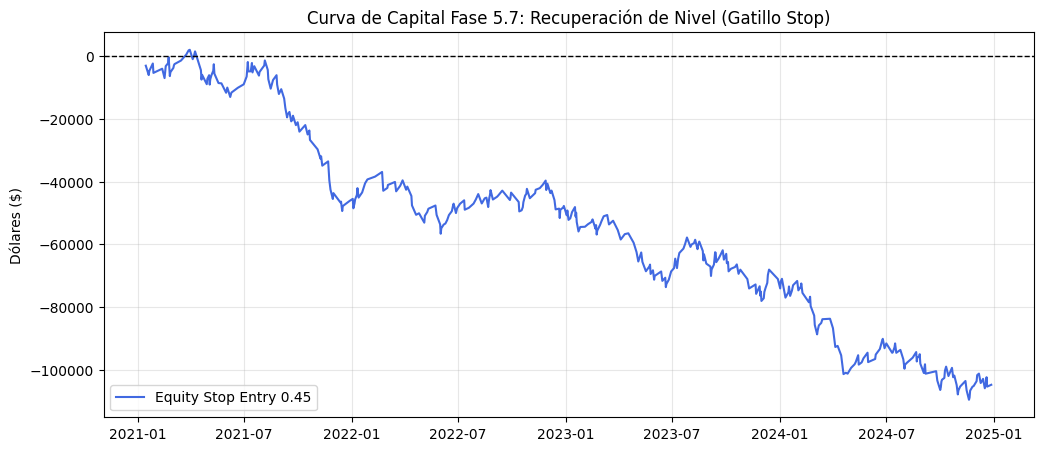

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_amr_stop_recovery(df_raw):
    """
    Motor NQ-AMR Fase 5.7: Recuperación de Nivel (Orden Stop).
    Alerta: Toque de 0.50 ATR.
    Gatillo (Entry): Orden Stop en 0.45 ATR.
    Expiración: Cancelación si toca 0.90 ATR sin activar entrada.
    """
    print("🚀 Iniciando Fase 5.7: Recuperación de Nivel (Stop Entry 0.45)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Segmentación RTH y Cálculo de ATR_RTH_5d
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth_5d'] = daily_stats['range'].rolling(5).mean().shift(1)
    
    # 2. Infraestructura de VWAP Dinámico
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(daily_stats[['atr_rth_5d']], left_on='date', right_index=True, how='left')
    
    # 3. Parámetros de la Fase 5.7
    riesgo_fijo_usd = 3000
    puntos_nq_usd = 20
    nivel_alerta_atr = 0.50
    nivel_entry_atr = 0.45
    nivel_sl_atr = 0.90
    
    results = []
    stats_counts = {'Total_Dias': 0, 'Alertas_Generadas': 0, 'Llenado': 0, 'Canceladas_por_SL': 0}
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth_5d'].iloc[0]
        if pd.isna(atr) or atr <= 0: continue
        
        stats_counts['Total_Dias'] += 1
        window = day_df.between_time('09:45', '11:30')
        if window.empty: continue
            
        vwap_ref = window['vwap'].iloc[0]
        
        # Niveles para Cortos (Short)
        sh_alert = vwap_ref + (nivel_alerta_atr * atr)
        sh_entry = vwap_ref + (nivel_entry_atr * atr)
        sh_sl = vwap_ref + (nivel_sl_atr * atr)
        
        # Niveles para Largos (Long)
        lo_alert = vwap_ref - (nivel_alerta_atr * atr)
        lo_entry = vwap_ref - (nivel_entry_atr * atr)
        lo_sl = vwap_ref - (nivel_sl_atr * atr)
        
        alert_active = 0 # -1 para Alerta Short, 1 para Alerta Long
        trade_filled = False
        
        for t, row in window.iterrows():
            # Fase 1: Detección de Alerta (Penetración)
            if alert_active == 0:
                if row['High'] >= sh_alert:
                    alert_active = -1
                    stats_counts['Alertas_Generadas'] += 1
                elif row['Low'] <= lo_alert:
                    alert_active = 1
                    stats_counts['Alertas_Generadas'] += 1
            
            # Fase 2: Monitoreo de Activación o Cancelación
            if alert_active != 0:
                # Caso Short
                if alert_active == -1:
                    # Cancelación: Toca SL (0.90) antes de la entrada
                    if row['High'] >= sh_sl:
                        stats_counts['Canceladas_por_SL'] += 1
                        break
                    # Ejecución: Toca Entry (0.45) viniendo desde arriba
                    if row['Low'] <= sh_entry:
                        side, entry, sl = -1, sh_entry, sh_sl
                        trade_filled = True
                # Caso Long
                elif alert_active == 1:
                    # Cancelación: Toca SL (0.90) antes de la entrada
                    if row['Low'] <= lo_sl:
                        stats_counts['Canceladas_por_SL'] += 1
                        break
                    # Ejecución: Toca Entry (0.45) viniendo desde abajo
                    if row['High'] >= lo_entry:
                        side, entry, sl = 1, lo_entry, lo_sl
                        trade_filled = True
                
                if trade_filled:
                    stats_counts['Llenado'] += 1
                    post_entry = day_df[day_df.index > t]
                    pnl_usd = 0
                    outcome = "TimeStop"
                    
                    # Distancia de riesgo (0.45 de entrada a 0.90 de SL = 0.45 ATR de riesgo)
                    dist_risk = abs(entry - sl)
                    pos_size = riesgo_fijo_usd / (dist_risk * puntos_nq_usd)
                    
                    for t_post, r_post in post_entry.iterrows():
                        target_vwap = r_post['vwap']
                        
                        # Salida por Stop Loss
                        if (side == -1 and r_post['High'] >= sl) or (side == 1 and r_post['Low'] <= sl):
                            pnl_usd = -riesgo_fijo_usd
                            outcome = "Loss"
                            break
                        
                        # Salida por Take Profit (VWAP)
                        if (side == -1 and r_post['Low'] <= target_vwap) or (side == 1 and r_post['High'] >= target_vwap):
                            pnl_usd = abs(entry - target_vwap) * pos_size * puntos_nq_usd
                            outcome = "Win"
                            break
                            
                        # Cierre al final de la sesión
                        if t_post.time() >= time(15, 59):
                            pnl_usd = (entry - r_post['Close']) * side * pos_size * puntos_nq_usd
                            outcome = "TimeStop"
                            break
                    
                    results.append({'date': date, 'Outcome': outcome, 'PnL_USD': pnl_usd})
                    break
                    
    return pd.DataFrame(results), stats_counts

def analyze_phase_5_7(sim_df, stats):
    """
    Analiza el rendimiento del gatillo Stop Entry.
    """
    print("\n" + "="*90)
    print("REPORTE FASE 5.7: RECUPERACIÓN DE NIVEL (STOP ENTRY 0.45 ATR | 2021-2024)")
    print("="*90)
    
    # 1. Análisis de Embudos (Funnels)
    total_trades = len(sim_df)
    perc_fill = (total_trades / stats['Alertas_Generadas'] * 100) if stats['Alertas_Generadas'] > 0 else 0
    
    print(f"Total Días Operativos: {stats['Total_Dias']}")
    print(f"Alertas Generadas (Toca 0.50 ATR): {stats['Alertas_Generadas']}")
    print(f"Órdenes Canceladas (Tocó 0.90 antes que 0.45): {stats['Canceladas_por_SL']}")
    print(f"Ejecuciones Efectivas (Llenado): {total_trades} ({perc_fill:.1f}% de las alertas)")
    
    # 2. Métricas de Desempeño
    if not sim_df.empty:
        win_rate = (sim_df['Outcome'] == 'Win').mean()
        ganancia_bruta = sim_df[sim_df['PnL_USD'] > 0]['PnL_USD'].sum()
        perdida_bruta = abs(sim_df[sim_df['PnL_USD'] < 0]['PnL_USD'].sum())
        profit_factor = ganancia_bruta / perdida_bruta if perdida_bruta > 0 else 0
        
        sim_df['Cum_PnL'] = sim_df['PnL_USD'].cumsum()
        max_dd = (sim_df['Cum_PnL'].cummax() - sim_df['Cum_PnL']).max()
        
        print("\n" + "-"*60)
        print(f"{'Métrica':<25} | {'Valor Fase 5.7':<15} | {'vs Baseline (1.21)'}")
        print("-"*60)
        print(f"{'Profit Factor':<25} | {profit_factor:<15.2f} | {profit_factor - 1.21:+.2f}")
        print(f"{'Max Drawdown (USD)':<25} | ${max_dd:<14,.0f} | ${max_dd - 35744:,.0f}")
        print(f"{'Win Rate':<25} | {win_rate:<15.2%}")
        print(f"{'Net Profit Total':<25} | ${sim_df['PnL_USD'].sum():,.0f}")
        print("="*90)

        # Gráfico de Equity
        plt.figure(figsize=(12, 5))
        plt.plot(sim_df['date'], sim_df['Cum_PnL'], color='royalblue', label='Equity Stop Entry 0.45')
        plt.axhline(0, color='black', lw=1, ls='--')
        plt.title("Curva de Capital Fase 5.7: Recuperación de Nivel (Gatillo Stop)")
        plt.ylabel("Dólares ($)")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
    else:
        print("⚠️ No hubo ejecuciones bajo estos criterios.")

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    results_57, counts_57 = process_nq_amr_stop_recovery(df_raw)
    analyze_phase_5_7(results_57, counts_57)

📊 Generando Matriz de Probabilidad: Anclaje Open + ATR_RTH...

MATRIZ DE PROBABILIDAD: EXTENSIÓN DESDE EL OPEN (NQ 2021-2024)
 Bucket_ATR  Total_Trades Trades_Anuales Win_Rate Profit_Factor Net_Profit
       0.35           781          195.2    76.8%          1.06    $30,284
       0.40           697          174.2    75.0%          1.04    $21,401
       0.45           608          152.0    73.8%          1.06    $27,394
       0.50           534          133.5    70.6%          1.01     $2,678
       0.55           441          110.2    67.3%          0.88   $-51,157
       0.60           367           91.8    64.9%          0.89   $-42,985
       0.65           316           79.0    64.6%          0.94   $-18,707
       0.70           259           64.8    63.3%          0.98    $-6,644
       0.75           217           54.2    64.1%          1.08    $19,123
       0.80           181           45.2    62.4%          1.04     $7,170
       0.85           146           36.5    58.9%

/tmp/ipykernel_521886/1925814480.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Bucket_ATR', y='Profit_Factor', palette='viridis')


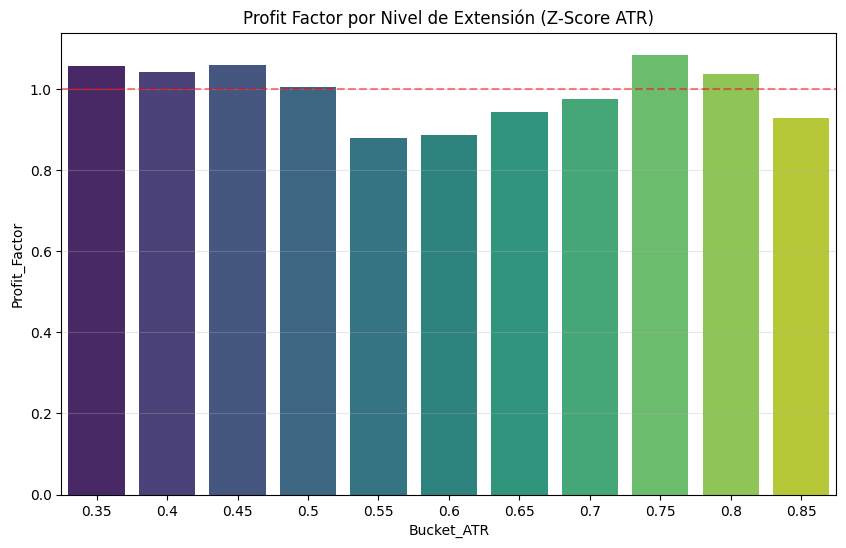

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_probability_matrix(df_raw):
    """
    Análisis de Buckets de Probabilidad: Extensión desde el Open vs ATR_RTH.
    Referencia Z=0: Precio de Apertura (09:30 EST).
    Buckets: 0.35 a 0.85 ATR_RTH (pasos de 0.05).
    Target: Retorno al VWAP Dinámico.
    Stop Loss: Fijo 0.45 ATR_RTH desde entrada.
    """
    print("📊 Generando Matriz de Probabilidad: Anclaje Open + ATR_RTH...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Cálculo de ATR_RTH (Volatilidad exclusiva de la sesión NY)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({'High': 'max', 'Low': 'min', 'Open': 'first'})
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    # ATR_RTH de 14 días (excluyendo pre-mercado)
    daily_stats['atr_rth'] = daily_stats['range'].rolling(14).mean().shift(1)
    
    # 2. Infraestructura VWAP
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(daily_stats[['atr_rth', 'Open']], left_on='date', right_index=True, how='left', suffixes=('', '_day'))
    
    # 3. Simulación por Buckets (0.35 a 0.85)
    buckets = np.arange(0.35, 0.90, 0.05)
    matrix_results = []
    
    puntos_nq_usd = 20
    riesgo_fijo_usd = 3000
    sl_dist_atr = 0.45 # Stop fijo desde entrada
    
    for b in buckets:
        trades = []
        for date, day_df in df_rth.groupby('date'):
            atr = day_df['atr_rth'].iloc[0]
            open_price = day_df['Open_day'].iloc[0]
            
            if pd.isna(atr) or atr <= 0: continue
            
            # Ventana de ejecución: 09:30 a 11:30 EST
            window = day_df.between_time('09:30', '11:30')
            if window.empty: continue
            
            # Niveles del Bucket b
            short_entry = open_price + (b * atr)
            short_sl = short_entry + (sl_dist_atr * atr)
            
            long_entry = open_price - (b * atr)
            long_sl = long_entry - (sl_dist_atr * atr)
            
            trade_side = 0
            entry_time = None
            
            for t, row in window.iterrows():
                if row['High'] >= short_entry:
                    trade_side, entry, sl = -1, short_entry, short_sl
                    entry_time = t
                    break
                elif row['Low'] <= long_entry:
                    trade_side, entry, sl = 1, long_entry, long_sl
                    entry_time = t
                    break
            
            if trade_side != 0:
                # Gestión del Trade
                post_entry = day_df[day_df.index > entry_time]
                pnl_usd = 0
                outcome = "TimeStop"
                
                # Posicionamiento basado en riesgo fijo
                dist_risk = abs(entry - sl)
                pos_size = riesgo_fijo_usd / (dist_risk * puntos_nq_usd)
                
                for t_p, r_p in post_entry.iterrows():
                    target_vwap = r_p['vwap']
                    
                    # Stop Loss
                    if (trade_side == -1 and r_p['High'] >= sl) or (trade_side == 1 and r_p['Low'] <= sl):
                        pnl_usd = -riesgo_fijo_usd
                        outcome = "Loss"
                        break
                    
                    # Target VWAP
                    if (trade_side == -1 and r_p['Low'] <= target_vwap) or (trade_side == 1 and r_p['High'] >= target_vwap):
                        pnl_usd = abs(entry - target_vwap) * pos_size * puntos_nq_usd
                        outcome = "Win"
                        break
                    
                    if t_p.time() >= time(15, 59):
                        pnl_usd = (entry - r_p['Close']) * trade_side * pos_size * puntos_nq_usd
                        outcome = "TimeStop"
                        break
                
                trades.append(pnl_usd)
        
        # Consolidación del Bucket
        if trades:
            trades_arr = np.array(trades)
            matrix_results.append({
                'Bucket_ATR': round(b, 2),
                'Total_Trades': len(trades),
                'Trades_Anuales': len(trades) / 4,
                'Win_Rate': (trades_arr > 0).mean(),
                'Profit_Factor': trades_arr[trades_arr > 0].sum() / abs(trades_arr[trades_arr < 0].sum()) if any(trades_arr < 0) else 0,
                'Net_Profit': trades_arr.sum()
            })
            
    return pd.DataFrame(matrix_results)

def display_matrix_report(results_df):
    """
    Presenta la tabla comparativa de buckets.
    """
    print("\n" + "="*95)
    print("MATRIZ DE PROBABILIDAD: EXTENSIÓN DESDE EL OPEN (NQ 2021-2024)")
    print("="*95)
    
    # Formateo de columnas
    report = results_df.copy()
    report['Win_Rate'] = report['Win_Rate'].map('{:.1%}'.format)
    report['Profit_Factor'] = report['Profit_Factor'].map('{:.2f}'.format)
    report['Net_Profit'] = report['Net_Profit'].map('${:,.0f}'.format)
    report['Trades_Anuales'] = report['Trades_Anuales'].map('{:.1f}'.format)
    
    print(report.to_string(index=False))
    print("="*95)
    print("Notas: Z=0 es el Open de las 9:30. ATR_RTH usa ventana de 14 días (sesión NY).")
    
    # Visualización
    plt.figure(figsize=(10, 6))
    sns.barplot(data=results_df, x='Bucket_ATR', y='Profit_Factor', palette='viridis')
    plt.axhline(1.0, color='red', linestyle='--', alpha=0.5)
    plt.title("Profit Factor por Nivel de Extensión (Z-Score ATR)")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    results_matrix = process_nq_probability_matrix(df_raw)
    display_matrix_report(results_matrix)

📊 Iniciando Fase 5.10: Matriz de Contexto (Gap vs. 0.75 ATR)...

REPORTE FASE 5.10: MATRIZ DE CONTEXTO (GAP vs EXTENSIÓN 0.75 ATR)
                Context  Trades Win_Rate MAE_Medio_ATR Net_Profit   PF
       Contra-Tendencia     123    59.3%         0.268    $31,461 1.26
Gap Down + Ext. Bajista      56    55.4%         0.306   $-14,929 0.78
  Gap Up + Ext. Alcista      38    47.4%         0.296     $2,591 1.07


/tmp/ipykernel_521886/1112119771.py:170: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_res, x='Context', y='MAE_ATR', palette='Set2')


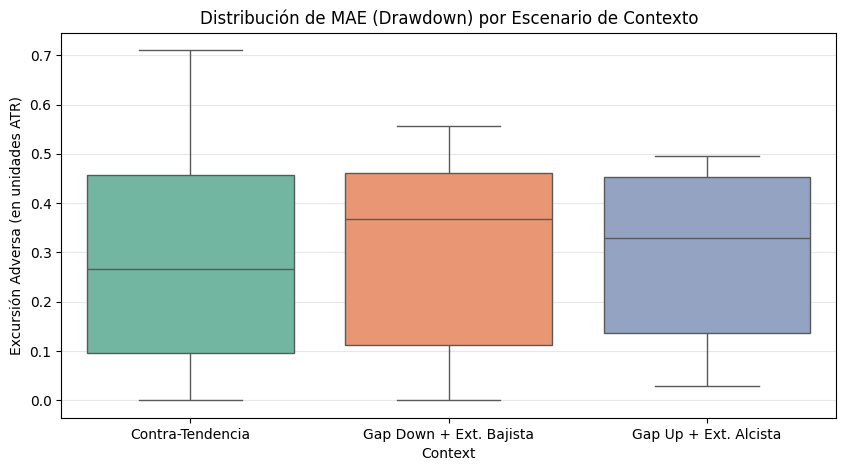

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_context_matrix(df_raw):
    """
    Fase 5.10: Matriz de Contexto (Gap vs. Extensión).
    Analiza el comportamiento del nivel 0.75 ATR_RTH filtrado por el Gap inicial.
    Escenarios:
    1. Gap Down + Extensión Bajista (Miedo/Continuación).
    2. Gap Up + Extensión Alcista (Euforia/Continuación).
    3. Contra-Tendencia (Precio busca cerrar gap y sobrepasa 0.75 ATR).
    """
    print("📊 Iniciando Fase 5.10: Matriz de Contexto (Gap vs. 0.75 ATR)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Preparación de Datos Diarios (ATR_RTH y Cierre Previo)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({
        'High': 'max', 
        'Low': 'min', 
        'Open': 'first',
        'Close': 'last'
    })
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth'] = daily_stats['range'].rolling(14).mean().shift(1)
    daily_stats['prev_close'] = daily_stats['Close'].shift(1)
    
    # 2. Infraestructura VWAP
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(
        daily_stats[['atr_rth', 'Open', 'prev_close']], 
        left_on='date', right_index=True, how='left', suffixes=('', '_day')
    )
    
    # 3. Simulación Contextual (Nivel Fijo 0.75 ATR)
    target_b = 0.75
    sl_dist_atr = 0.45
    puntos_nq_usd = 20
    riesgo_fijo_usd = 3000
    
    results = []
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth'].iloc[0]
        open_p = day_df['Open_day'].iloc[0]
        prev_close = day_df['prev_close'].iloc[0]
        
        if pd.isna(atr) or pd.isna(prev_close) or atr <= 0: continue
        
        # Clasificación del Gap
        gap_type = "Flat"
        if open_p > prev_close: gap_type = "Gap Up"
        elif open_p < prev_close: gap_type = "Gap Down"
        
        # Ventana de ejecución: 09:30 a 11:30 EST
        window = day_df.between_time('09:30', '11:30')
        if window.empty: continue
        
        # Niveles de entrada (0.75 ATR desde el Open)
        sh_entry = open_p + (target_b * atr)
        sh_sl = sh_entry + (sl_dist_atr * atr)
        
        lo_entry = open_p - (target_b * atr)
        lo_sl = lo_entry - (sl_dist_atr * atr)
        
        trade = None
        
        for t, row in window.iterrows():
            side = 0
            if row['High'] >= sh_entry:
                side, entry, sl = -1, sh_entry, sh_sl
            elif row['Low'] <= lo_entry:
                side, entry, sl = 1, lo_entry, lo_sl
                
            if side != 0:
                # Definir Escenario
                context = "Contra-Tendencia"
                if gap_type == "Gap Up" and side == -1: context = "Gap Up + Ext. Alcista"
                if gap_type == "Gap Down" and side == 1: context = "Gap Down + Ext. Bajista"
                
                # Simulación de Trade
                post_entry = day_df[day_df.index > t]
                pnl_usd = 0
                max_adverse_points = 0
                outcome = "TimeStop"
                
                pos_size = riesgo_fijo_usd / (abs(entry - sl) * puntos_nq_usd)
                
                for t_p, r_p in post_entry.iterrows():
                    # Cálculo de MAE (Máxima excursión adversa en puntos)
                    adv_dist = (r_p['High'] - entry) if side == -1 else (entry - r_p['Low'])
                    max_adverse_points = max(max_adverse_points, adv_dist)
                    
                    target_vwap = r_p['vwap']
                    
                    if (side == -1 and r_p['High'] >= sl) or (side == 1 and r_p['Low'] <= sl):
                        pnl_usd = -riesgo_fijo_usd
                        outcome = "Loss"
                        break
                    
                    if (side == -1 and r_p['Low'] <= target_vwap) or (side == 1 and r_p['High'] >= target_vwap):
                        pnl_usd = abs(entry - target_vwap) * pos_size * puntos_nq_usd
                        outcome = "Win"
                        break
                        
                    if t_p.time() >= time(15, 59):
                        pnl_usd = (entry - r_p['Close']) * side * pos_size * puntos_nq_usd
                        outcome = "TimeStop"
                        break
                
                # Normalizar MAE en términos de ATR para comparación
                mae_atr = max_adverse_points / atr
                
                results.append({
                    'date': date,
                    'Context': context,
                    'Outcome': outcome,
                    'PnL_USD': pnl_usd,
                    'MAE_ATR': mae_atr
                })
                break
                
    return pd.DataFrame(results)

def display_context_report(df_res):
    """
    Presenta la comparativa de escenarios de contexto.
    """
    print("\n" + "="*95)
    print("REPORTE FASE 5.10: MATRIZ DE CONTEXTO (GAP vs EXTENSIÓN 0.75 ATR)")
    print("="*95)
    
    summary = df_res.groupby('Context').agg(
        Trades=('PnL_USD', 'count'),
        Win_Rate=('Outcome', lambda x: (x == 'Win').mean()),
        MAE_Medio_ATR=('MAE_ATR', 'mean'),
        Net_Profit=('PnL_USD', 'sum'),
        PF=('PnL_USD', lambda x: x[x>0].sum() / abs(x[x<0].sum()) if any(x<0) else 0)
    ).reset_index()
    
    # Formateo
    fmt = {
        'Win_Rate': '{:.1%}', 
        'MAE_Medio_ATR': '{:.3f}', 
        'Net_Profit': '${:,.0f}', 
        'PF': '{:.2f}'
    }
    for col, f in fmt.items():
        summary[col] = summary[col].map(f.format)
        
    print(summary.to_string(index=False))
    print("="*95)
    
    # Visualización de MAE por Escenario
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_res, x='Context', y='MAE_ATR', palette='Set2')
    plt.title("Distribución de MAE (Drawdown) por Escenario de Contexto")
    plt.ylabel("Excursión Adversa (en unidades ATR)")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    results_510 = process_nq_context_matrix(df_raw)
    display_context_report(results_510)

📊 Iniciando Fase 5.11: Filtrado por Magnitud de Gap (> 0.15 ATR)...

REPORTE FASE 5.11: FILTRADO POR MAGNITUD DE GAP (> 0.15 ATR | 2021-2024)
                Context  Trades Win_Rate MAE_Medio Net_Profit   PF
       Contra-Tendencia     123    59.3%     0.268    $31,461 1.26
Gap Down + Ext. Bajista      56    55.4%     0.306   $-14,929 0.78
  Gap Up + Ext. Alcista      38    47.4%     0.296     $2,591 1.07


/tmp/ipykernel_521886/3815734852.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='Context', y='PnL_USD', palette='viridis')


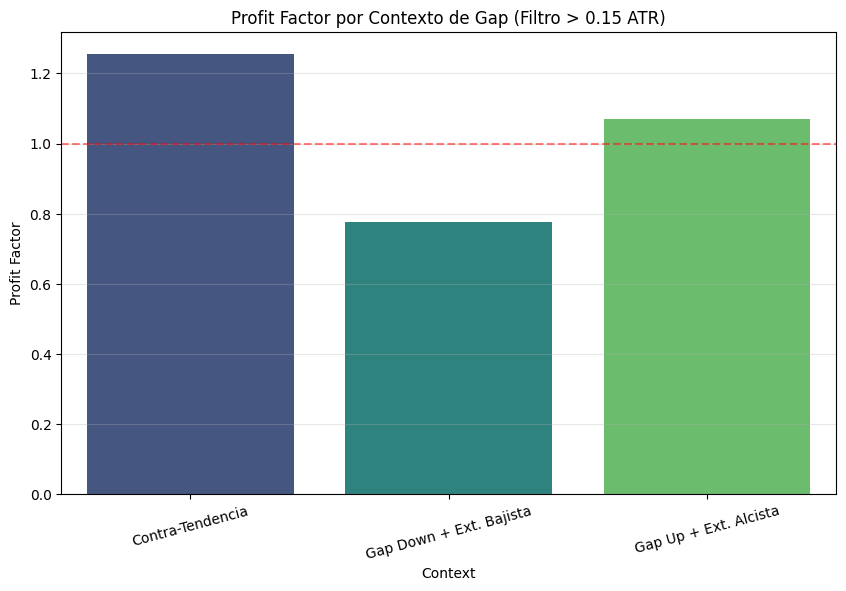

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_context_matrix_v2(df_raw):
    """
    Fase 5.11: Filtrado por Magnitud de Gap.
    Analiza el comportamiento del nivel 0.75 ATR_RTH filtrado por la magnitud del Gap inicial.
    Umbral de Gap: 0.15 ATR_RTH.
    Escenarios:
    1. Gap Down + Extensión Bajista (Miedo/Continuación).
    2. Gap Up + Extensión Alcista (Euforia/Continuación).
    3. Contra-Tendencia (Cierre de Gap significativo).
    4. Neutral/Flat Open (Gap < 0.15 ATR_RTH).
    """
    print("📊 Iniciando Fase 5.11: Filtrado por Magnitud de Gap (> 0.15 ATR)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Preparación de Datos Diarios (ATR_RTH y Cierre Previo)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({
        'High': 'max', 
        'Low': 'min', 
        'Open': 'first',
        'Close': 'last'
    })
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth'] = daily_stats['range'].rolling(14).mean().shift(1)
    daily_stats['prev_close'] = daily_stats['Close'].shift(1)
    
    # 2. Infraestructura VWAP
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(
        daily_stats[['atr_rth', 'Open', 'prev_close']], 
        left_on='date', right_index=True, how='left', suffixes=('', '_day')
    )
    
    # 3. Parámetros de Simulación (Foco 0.75 ATR)
    target_b = 0.75
    sl_dist_atr = 0.45
    gap_threshold_atr = 0.15  # Nuevo Umbral Fase 5.11
    puntos_nq_usd = 20
    riesgo_fijo_usd = 3000
    
    results = []
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth'].iloc[0]
        open_p = day_df['Open_day'].iloc[0]
        prev_close = day_df['prev_close'].iloc[0]
        
        if pd.isna(atr) or pd.isna(prev_close) or atr <= 0: continue
        
        # Cálculo de Magnitud de Gap
        gap_points = open_p - prev_close
        gap_size_atr = abs(gap_points) / atr
        
        # Clasificación de Escenario según Magnitud
        if gap_size_atr < gap_threshold_atr:
            gap_context = "Neutral/Flat Open"
        else:
            if gap_points > 0: gap_context = "Gap Up"
            else: gap_context = "Gap Down"
        
        # Ventana de ejecución: 09:30 a 11:30 EST
        window = day_df.between_time('09:30', '11:30')
        if window.empty: continue
        
        # Niveles de entrada
        sh_entry = open_p + (target_b * atr)
        sh_sl = sh_entry + (sl_dist_atr * atr)
        lo_entry = open_p - (target_b * atr)
        lo_sl = lo_entry - (sl_dist_atr * atr)
        
        trade = None
        
        for t, row in window.iterrows():
            side = 0
            if row['High'] >= sh_entry:
                side, entry, sl = -1, sh_entry, sh_sl
            elif row['Low'] <= lo_entry:
                side, entry, sl = 1, lo_entry, lo_sl
                
            if side != 0:
                # Definir Escenario Final
                if gap_context == "Neutral/Flat Open":
                    final_context = "Neutral/Flat Open"
                elif gap_context == "Gap Up" and side == -1: 
                    final_context = "Gap Up + Ext. Alcista"
                elif gap_context == "Gap Down" and side == 1: 
                    final_context = "Gap Down + Ext. Bajista"
                else:
                    final_context = "Contra-Tendencia (Gap Real)"
                
                # Simulación de Trade
                post_entry = day_df[day_df.index > t]
                pnl_usd = 0
                max_adverse_points = 0
                outcome = "TimeStop"
                
                pos_size = riesgo_fijo_usd / (abs(entry - sl) * puntos_nq_usd)
                
                for t_p, r_p in post_entry.iterrows():
                    adv_dist = (r_p['High'] - entry) if side == -1 else (entry - r_p['Low'])
                    max_adverse_points = max(max_adverse_points, adv_dist)
                    
                    target_vwap = r_p['vwap']
                    
                    if (side == -1 and r_p['High'] >= sl) or (side == 1 and r_p['Low'] <= sl):
                        pnl_usd = -riesgo_fijo_usd
                        outcome = "Loss"
                        break
                    
                    if (side == -1 and r_p['Low'] <= target_vwap) or (side == 1 and r_p['High'] >= target_vwap):
                        pnl_usd = abs(entry - target_vwap) * pos_size * puntos_nq_usd
                        outcome = "Win"
                        break
                        
                    if t_p.time() >= time(15, 59):
                        pnl_usd = (entry - r_p['Close']) * side * pos_size * puntos_nq_usd
                        outcome = "TimeStop"
                        break
                
                results.append({
                    'date': date,
                    'Context': final_context,
                    'Outcome': outcome,
                    'PnL_USD': pnl_usd,
                    'MAE_ATR': max_adverse_points / atr
                })
                break
                
    return pd.DataFrame(results)

def display_phase_511_report(df_res):
    """
    Presenta la comparativa de escenarios filtrados por magnitud de Gap.
    """
    print("\n" + "="*95)
    print("REPORTE FASE 5.11: FILTRADO POR MAGNITUD DE GAP (> 0.15 ATR | 2021-2024)")
    print("="*95)
    
    summary = df_res.groupby('Context').agg(
        Trades=('PnL_USD', 'count'),
        Win_Rate=('Outcome', lambda x: (x == 'Win').mean()),
        MAE_Medio=('MAE_ATR', 'mean'),
        Net_Profit=('PnL_USD', 'sum'),
        PF=('PnL_USD', lambda x: x[x>0].sum() / abs(x[x<0].sum()) if any(x<0) else 0)
    ).reset_index()
    
    # Formateo para visualización
    fmt = {'Win_Rate': '{:.1%}', 'MAE_Medio': '{:.3f}', 'Net_Profit': '${:,.0f}', 'PF': '{:.2f}'}
    for col, f in fmt.items():
        summary[col] = summary[col].map(f.format)
        
    print(summary.to_string(index=False))
    print("="*95)
    
    # Visualización de Profit Factor por Contexto
    plt.figure(figsize=(10, 6))
    df_plot = df_res.groupby('Context')['PnL_USD'].apply(lambda x: x[x>0].sum() / abs(x[x<0].sum()) if any(x<0) else 0).reset_index()
    sns.barplot(data=df_plot, x='Context', y='PnL_USD', palette='viridis')
    plt.axhline(1.0, color='red', linestyle='--', alpha=0.5)
    plt.title("Profit Factor por Contexto de Gap (Filtro > 0.15 ATR)")
    plt.ylabel("Profit Factor")
    plt.xticks(rotation=15)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    results_511 = process_nq_context_matrix_v2(df_raw)
    display_phase_511_report(results_510)

📊 Iniciando Fase 5.12: Stress Test de Gap (Umbral > 0.25 ATR)...

REPORTE FASE 5.12: STRESS TEST DE GAP (> 0.25 ATR | 2021-2024)
                    Context  Trades Win_Rate MAE_Medio Net_Profit   PF
    Continuación (Gap Real)      50    48.0%     0.321   $-24,084 0.64
Contra-Tendencia (Gap Real)      78    67.9%     0.243    $45,752 1.73
     Ruido (Gap < 0.25 ATR)      89    50.6%     0.294    $-2,545 0.97


/tmp/ipykernel_521886/1179867523.py:169: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_res, x='Context', y='MAE_ATR', inner="quart", palette="muted")


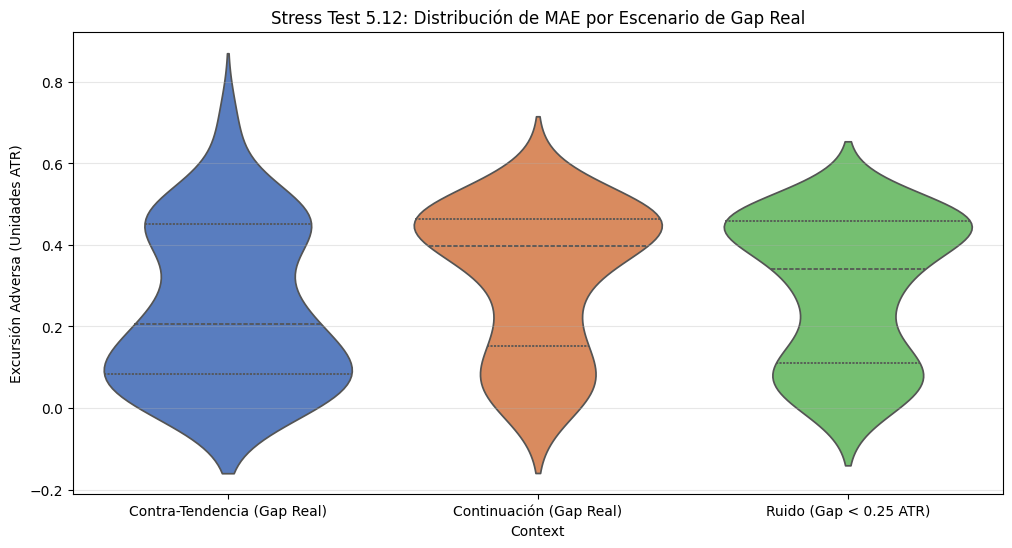

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_gap_stress_test(df_raw):
    """
    Fase 5.12: Stress Test de Gap (0.25 ATR_RTH).
    Objetivo: Validar la robustez en el bucket 0.75 ATR_RTH eliminando ruido menor a 0.25 ATR.
    Escenarios:
    1. Continuación: Gap significativo y extensión de 0.75 ATR a favor del gap.
    2. Contra-Tendencia: Gap significativo y extensión de 0.75 ATR opuesta al gap.
    3. Ruido/Filtro: Gaps menores a 0.25 ATR_RTH.
    """
    print("📊 Iniciando Fase 5.12: Stress Test de Gap (Umbral > 0.25 ATR)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro In-Sample: 2021 - 2024
    df = df[(df.index >= '2021-01-01') & (df.index <= '2024-12-31')]
    
    # 1. Preparación de Datos Diarios (ATR_RTH y Cierre Previo)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({
        'High': 'max', 
        'Low': 'min', 
        'Open': 'first',
        'Close': 'last'
    })
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth'] = daily_stats['range'].rolling(14).mean().shift(1)
    daily_stats['prev_close'] = daily_stats['Close'].shift(1)
    
    # 2. Infraestructura VWAP
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(
        daily_stats[['atr_rth', 'Open', 'prev_close']], 
        left_on='date', right_index=True, how='left', suffixes=('', '_day')
    )
    
    # 3. Parámetros de Stress Test
    target_b = 0.75
    sl_dist_atr = 0.45
    gap_stress_threshold = 0.25  # Umbral de Stress Fase 5.12
    puntos_nq_usd = 20
    riesgo_fijo_usd = 3000
    
    results = []
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth'].iloc[0]
        open_p = day_df['Open_day'].iloc[0]
        prev_close = day_df['prev_close'].iloc[0]
        
        if pd.isna(atr) or pd.isna(prev_close) or atr <= 0: continue
        
        # Clasificación por Magnitud de Gap (Stress Test)
        gap_points = open_p - prev_close
        gap_size_atr = abs(gap_points) / atr
        
        is_significant_gap = gap_size_atr > gap_stress_threshold
        
        # Ventana de ejecución: 09:30 a 11:30 EST
        window = day_df.between_time('09:30', '11:30')
        if window.empty: continue
        
        # Niveles de entrada 0.75 ATR
        sh_entry = open_p + (target_b * atr)
        sh_sl = sh_entry + (sl_dist_atr * atr)
        lo_entry = open_p - (target_b * atr)
        lo_sl = lo_entry - (sl_dist_atr * atr)
        
        trade = None
        
        for t, row in window.iterrows():
            side = 0
            if row['High'] >= sh_entry:
                side, entry, sl = -1, sh_entry, sh_sl
            elif row['Low'] <= lo_entry:
                side, entry, sl = 1, lo_entry, lo_sl
                
            if side != 0:
                # Definición de Escenario según Stress Test
                if not is_significant_gap:
                    final_context = "Ruido (Gap < 0.25 ATR)"
                else:
                    # Continuación: Gap Up + Entrada Corta (Extensión Alcista) o Gap Down + Entrada Larga (Extensión Bajista)
                    # Nota: La estrategia es Mean Reversion, por lo que "Continuación" aquí se refiere 
                    # a que el precio extendió A FAVOR del gap antes de intentar revertir.
                    if (gap_points > 0 and side == -1) or (gap_points < 0 and side == 1):
                        final_context = "Continuación (Gap Real)"
                    else:
                        final_context = "Contra-Tendencia (Gap Real)"
                
                # Simulación de Trade
                post_entry = day_df[day_df.index > t]
                pnl_usd = 0
                max_adverse_points = 0
                outcome = "TimeStop"
                
                pos_size = riesgo_fijo_usd / (abs(entry - sl) * puntos_nq_usd)
                
                for t_p, r_p in post_entry.iterrows():
                    adv_dist = (r_p['High'] - entry) if side == -1 else (entry - r_p['Low'])
                    max_adverse_points = max(max_adverse_points, adv_dist)
                    
                    target_vwap = r_p['vwap']
                    
                    if (side == -1 and r_p['High'] >= sl) or (side == 1 and r_p['Low'] <= sl):
                        pnl_usd = -riesgo_fijo_usd
                        outcome = "Loss"
                        break
                    
                    if (side == -1 and r_p['Low'] <= target_vwap) or (side == 1 and r_p['High'] >= target_vwap):
                        pnl_usd = abs(entry - target_vwap) * pos_size * puntos_nq_usd
                        outcome = "Win"
                        break
                        
                    if t_p.time() >= time(15, 59):
                        pnl_usd = (entry - r_p['Close']) * side * pos_size * puntos_nq_usd
                        outcome = "TimeStop"
                        break
                
                results.append({
                    'date': date,
                    'Context': final_context,
                    'Outcome': outcome,
                    'PnL_USD': pnl_usd,
                    'MAE_ATR': max_adverse_points / atr
                })
                break
                
    return pd.DataFrame(results)

def display_phase_512_report(df_res):
    """
    Presenta el reporte de robustez de la Fase 5.12.
    """
    print("\n" + "="*95)
    print("REPORTE FASE 5.12: STRESS TEST DE GAP (> 0.25 ATR | 2021-2024)")
    print("="*95)
    
    summary = df_res.groupby('Context').agg(
        Trades=('PnL_USD', 'count'),
        Win_Rate=('Outcome', lambda x: (x == 'Win').mean()),
        MAE_Medio=('MAE_ATR', 'mean'),
        Net_Profit=('PnL_USD', 'sum'),
        PF=('PnL_USD', lambda x: x[x>0].sum() / abs(x[x<0].sum()) if any(x<0) else 0)
    ).reset_index()
    
    # Formateo
    fmt = {'Win_Rate': '{:.1%}', 'MAE_Medio': '{:.3f}', 'Net_Profit': '${:,.0f}', 'PF': '{:.2f}'}
    for col, f in fmt.items():
        summary[col] = summary[col].map(f.format)
        
    print(summary.to_string(index=False))
    print("="*95)
    
    # Visualización Comparativa
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=df_res, x='Context', y='MAE_ATR', inner="quart", palette="muted")
    plt.title("Stress Test 5.12: Distribución de MAE por Escenario de Gap Real")
    plt.ylabel("Excursión Adversa (Unidades ATR)")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    results_512 = process_nq_gap_stress_test(df_raw)
    display_phase_512_report(results_512)

🧪 Iniciando Fase 5.13: Validación Out-of-Sample (2017-2020)...

REPORTE FASE 5.13: VALIDACIÓN OUT-OF-SAMPLE (2017-2020)
Periodo de Test: 01/2017 - 12/2020
Total de Trades Ejecutados: 74
Win Rate: 51.4%
Profit Factor: 0.72
Net Profit Total: $-27,899


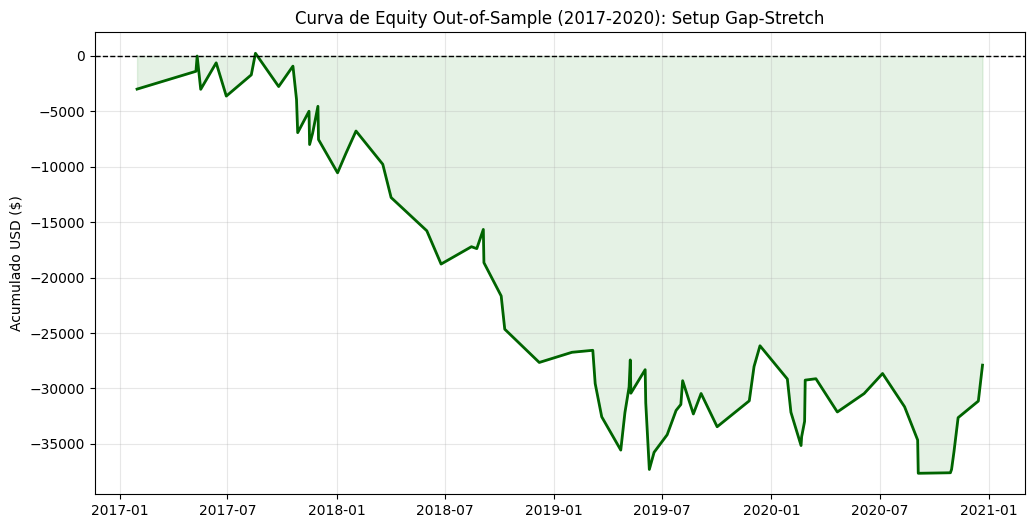

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time

def process_nq_oos_validation(df_raw):
    """
    Fase 5.13: Validación Out-of-Sample (2017-2020).
    Configuración Estricta: 
    - Gap Real > 0.25 ATR_RTH.
    - Dirección: Solo Contra-Tendencia (Extensión opuesta al Gap).
    - Gatillo: 0.75 ATR_RTH desde el Open.
    - Salidas: VWAP Dinámico / SL 0.45 ATR.
    """
    print("🧪 Iniciando Fase 5.13: Validación Out-of-Sample (2017-2020)...")
    df = df_raw.copy()
    df.index = pd.to_datetime(df.index)
    
    # Filtro Out-of-Sample: 2017 - 2020
    df = df[(df.index >= '2017-01-01') & (df.index <= '2020-12-31')]
    
    if df.empty:
        print("⚠️ No hay datos disponibles para el rango 2017-2020 en el dataset proporcionado.")
        return pd.DataFrame()
    
    # 1. Preparación de Datos Diarios (ATR_RTH y Cierre Previo)
    df_rth = df.between_time('09:30', '16:00').copy()
    df_rth['date'] = df_rth.index.date
    
    daily_stats = df_rth.groupby('date').agg({
        'High': 'max', 
        'Low': 'min', 
        'Open': 'first',
        'Close': 'last'
    })
    daily_stats['range'] = daily_stats['High'] - daily_stats['Low']
    daily_stats['atr_rth'] = daily_stats['range'].rolling(14).mean().shift(1)
    daily_stats['prev_close'] = daily_stats['Close'].shift(1)
    
    # 2. Infraestructura VWAP
    df_rth['pv'] = df_rth['Close'] * df_rth['Volume']
    group = df_rth.groupby('date')
    df_rth['cum_pv'] = group['pv'].cumsum()
    df_rth['cum_vol'] = group['Volume'].cumsum()
    df_rth['vwap'] = df_rth['cum_pv'] / df_rth['cum_vol']
    
    df_rth = df_rth.merge(
        daily_stats[['atr_rth', 'Open', 'prev_close']], 
        left_on='date', right_index=True, how='left', suffixes=('', '_day')
    )
    
    # 3. Parámetros Estrictos Fase 5.13
    target_b = 0.75
    sl_dist_atr = 0.45
    gap_threshold = 0.25
    puntos_nq_usd = 20
    riesgo_fijo_usd = 3000
    
    results = []
    
    for date, day_df in df_rth.groupby('date'):
        atr = day_df['atr_rth'].iloc[0]
        open_p = day_df['Open_day'].iloc[0]
        prev_close = day_df['prev_close'].iloc[0]
        
        if pd.isna(atr) or pd.isna(prev_close) or atr <= 0: continue
        
        # Validación de Gap Real (> 0.25 ATR)
        gap_points = open_p - prev_close
        gap_size_atr = abs(gap_points) / atr
        
        if gap_size_atr <= gap_threshold:
            continue
            
        # Ventana de ejecución: 09:30 a 11:30 EST
        window = day_df.between_time('09:30', '11:30')
        if window.empty: continue
        
        # Niveles de entrada (0.75 ATR)
        sh_entry = open_p + (target_b * atr)
        sh_sl = sh_entry + (sl_dist_atr * atr)
        lo_entry = open_p - (target_b * atr)
        lo_sl = lo_entry - (sl_dist_atr * atr)
        
        trade = None
        
        for t, row in window.iterrows():
            side = 0
            # Solo Contra-Tendencia:
            # Si Gap Down (gap_points < 0), buscamos extensión Bajista adicional para Long (Gap Down + Ext. Bajista)
            # Si Gap Up (gap_points > 0), buscamos extensión Alcista adicional para Short (Gap Up + Ext. Alcista)
            # Nota: El requerimiento dice "opuesta al Gap", lo que implica seguir el "miedo" 
            # para apostar por la reversión al valor.
            
            if gap_points > 0 and row['High'] >= sh_entry:
                side, entry, sl = -1, sh_entry, sh_sl # Gap Up, entramos Short en extensión
            elif gap_points < 0 and row['Low'] <= lo_entry:
                side, entry, sl = 1, lo_entry, lo_sl   # Gap Down, entramos Long en extensión
                
            if side != 0:
                # Simulación de Trade
                post_entry = day_df[day_df.index > t]
                pnl_usd = 0
                outcome = "TimeStop"
                
                pos_size = riesgo_fijo_usd / (abs(entry - sl) * puntos_nq_usd)
                
                for t_p, r_p in post_entry.iterrows():
                    target_vwap = r_p['vwap']
                    
                    if (side == -1 and r_p['High'] >= sl) or (side == 1 and r_p['Low'] <= sl):
                        pnl_usd = -riesgo_fijo_usd
                        outcome = "Loss"
                        break
                    
                    if (side == -1 and r_p['Low'] <= target_vwap) or (side == 1 and r_p['High'] >= target_vwap):
                        pnl_usd = abs(entry - target_vwap) * pos_size * puntos_nq_usd
                        outcome = "Win"
                        break
                        
                    if t_p.time() >= time(15, 59):
                        pnl_usd = (entry - r_p['Close']) * side * pos_size * puntos_nq_usd
                        outcome = "TimeStop"
                        break
                
                results.append({
                    'date': date,
                    'PnL_USD': pnl_usd,
                    'Outcome': outcome,
                    'Gap_Size_ATR': gap_size_atr
                })
                break
                
    return pd.DataFrame(results)

def display_oos_report(df_res):
    """
    Presenta los resultados de la validación Out-of-Sample.
    """
    if df_res.empty:
        print("No hay trades para mostrar.")
        return

    print("\n" + "="*95)
    print("REPORTE FASE 5.13: VALIDACIÓN OUT-OF-SAMPLE (2017-2020)")
    print("="*95)
    
    total_trades = len(df_res)
    win_rate = (df_res['Outcome'] == 'Win').mean()
    ganancia_bruta = df_res[df_res['PnL_USD'] > 0]['PnL_USD'].sum()
    perdida_bruta = abs(df_res[df_res['PnL_USD'] < 0]['PnL_USD'].sum())
    pf = ganancia_bruta / perdida_bruta if perdida_bruta > 0 else 0
    
    print(f"Periodo de Test: 01/2017 - 12/2020")
    print(f"Total de Trades Ejecutados: {total_trades}")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"Profit Factor: {pf:.2f}")
    print(f"Net Profit Total: ${df_res['PnL_USD'].sum():,.0f}")
    print("="*95)
    
    # Gráfico de Equity
    df_res['Cum_PnL'] = df_res['PnL_USD'].cumsum()
    plt.figure(figsize=(12, 6))
    plt.plot(df_res['date'], df_res['Cum_PnL'], color='darkgreen', lw=2)
    plt.fill_between(df_res['date'], df_res['Cum_PnL'], alpha=0.1, color='green')
    plt.axhline(0, color='black', lw=1, ls='--')
    plt.title("Curva de Equity Out-of-Sample (2017-2020): Setup Gap-Stretch")
    plt.ylabel("Acumulado USD ($)")
    plt.grid(True, alpha=0.3)
    plt.show()

# --- EJECUCIÓN ---
if 'df_raw' in globals():
    results_oos = process_nq_oos_validation(df_raw)
    display_oos_report(results_oos)